# Calculating the design matrix
- Map response as a regressor
- Then split it up based on valence and volatility
- See how they are correlated amongst each other

In [62]:
import utils
import numpy as np
import pandas as pd
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns # Loads in the theme

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math
import random
import os
from scipy.stats import skewnorm
from nilearn.glm.first_level import compute_regressor
from nilearn.glm.first_level import spm_hrf
from nilearn.glm.first_level import make_first_level_design_matrix, check_design_matrix
from nilearn.plotting import plot_design_matrix

#plt.rcParams.update(plt.rcParamsDefault)
#pd.set_option('display.max_rows', None)

In [63]:
# Make output folder
output_dir = os.path.join('..','plots','fMRI','design_matrices')
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

In [64]:
# Preparation
plot_range = [0, 6]

# Loads the datapath, subject_id's and session numbers
raw_output_path = '/Volumes/project/3025011.02/raw/'
unique_subject_ids = [5, 10, 14, 15, 16, 20, 22, 23, 25, 28, 29, 37, 38]
unique_sessions = [2,3,4]

# Load and combine the datasets
combined_dataframe = utils.import_functions.main(raw_output_path, unique_subject_ids, unique_sessions, block_isolated='block_2')

# Shorten the experiment to check if it still works with 448 trials
combined_dataframe = combined_dataframe[combined_dataframe['trial'] <= 449]

print(combined_dataframe)

/Volumes/kenvdzee/Documents/phd_1_analysis/utils/import_functions.py:631: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataframe['objectively_correct_boolean'] = dataframe['objectively_correct'].replace(mapping)


      subject_id     session subjectively_correct_one_back subjectively_correct  same_response_as_one_back  WS_subjective  LS_subjective
0        sub-005  session-02                           NaN                False                          0              0              0
1        sub-005  session-02                         False                False                          1              0             -1
2        sub-005  session-02                         False                False                          1              0             -1
3        sub-005  session-02                         False                 True                          0              0              1
4        sub-005  session-02                          True                 True                          1              1              0
...          ...         ...                           ...                  ...                        ...            ...            ...
17155    sub-038  session-04             

/Volumes/kenvdzee/Documents/phd_1_analysis/utils/import_functions.py:673: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataframe['response_boolean'] = dataframe['response'].replace(mapping)
/Volumes/kenvdzee/Documents/phd_1_analysis/utils/import_functions.py:674: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataframe['correct_response_boolean'] = dataframe['correct_response'].replace(mapping)


Creating event file for subject 5 and session 2
    valence   congruency volatility congruency-volatility  duration
0     angry  incongruent   volatile  incongruent-volatile       1.8
0     happy  incongruent   volatile  incongruent-volatile       1.8
1     happy  incongruent   volatile  incongruent-volatile       1.8
1     angry  incongruent   volatile  incongruent-volatile       1.8
2     angry  incongruent   volatile  incongruent-volatile       1.8
..      ...          ...        ...                   ...       ...
217   happy  incongruent   volatile  incongruent-volatile       1.8
218   angry  incongruent   volatile  incongruent-volatile       1.8
219   angry  incongruent   volatile  incongruent-volatile       1.8
220   angry  incongruent   volatile  incongruent-volatile       1.8
218   happy  incongruent   volatile  incongruent-volatile       1.8

[438 rows x 5 columns]
                trial_type        onset  duration
0              incongruent     0.000000       1.8
1           

/Users/kenneth.van.der.zee/Documents/phd_1_analysis/venv/lib/python3.10/site-packages/nilearn/glm/_utils.py:180: UserWarning: Matrix is singular at working precision, regularizing...
  warn("Matrix is singular at working precision, regularizing...")


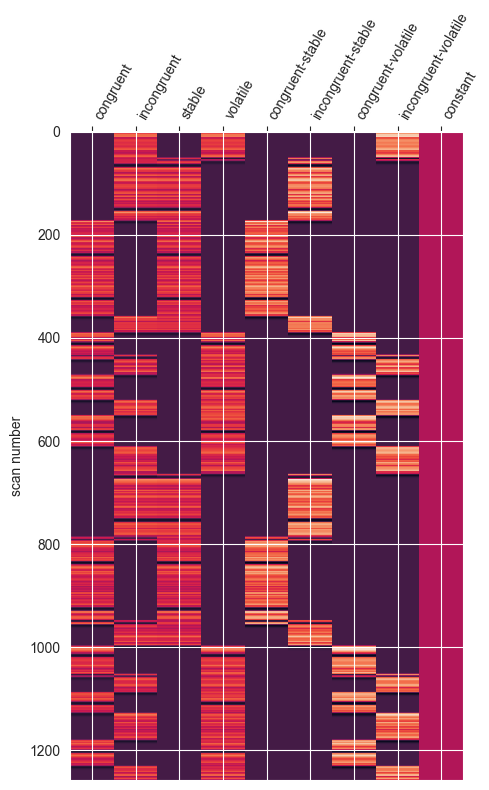

                      congruent  incongruent    stable  volatile  congruent-stable  incongruent-stable  congruent-volatile  incongruent-volatile  constant
congruent              1.000000    -0.790889  0.133011  0.083993          0.627845           -0.478644            0.579836             -0.476047 -0.506110
incongruent           -0.790889     1.000000  0.098025  0.111599         -0.495121            0.617217           -0.460087              0.589575 -0.004396
stable                 0.133011     0.098025  1.000000 -0.782207          0.594038            0.579977           -0.457275             -0.475495 -0.429581
volatile               0.083993     0.111599 -0.782207  1.000000         -0.466830           -0.451465            0.592561              0.599978 -0.089280
congruent-stable       0.627845    -0.495121  0.594038 -0.466830          1.000000           -0.310792           -0.270091             -0.286578 -0.482558
incongruent-stable    -0.478644     0.617217  0.579977 -0.451465      

/Users/kenneth.van.der.zee/Documents/phd_1_analysis/venv/lib/python3.10/site-packages/nilearn/glm/_utils.py:180: UserWarning: Matrix is singular at working precision, regularizing...
  warn("Matrix is singular at working precision, regularizing...")


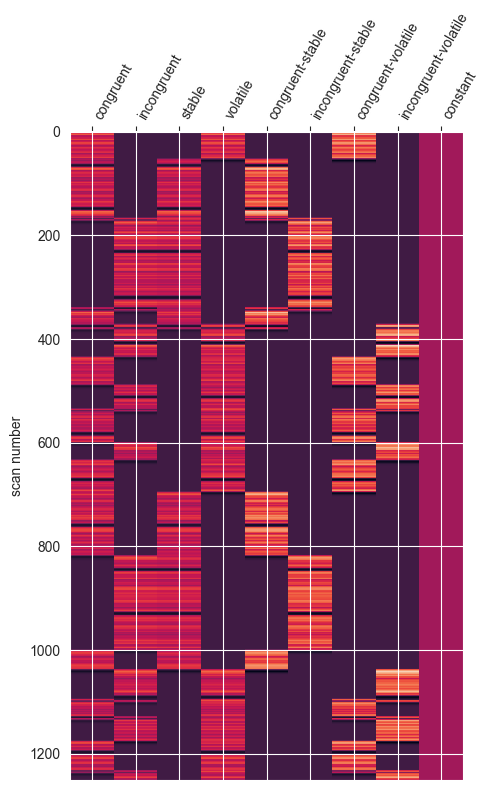

                      congruent  incongruent    stable  volatile  congruent-stable  incongruent-stable  congruent-volatile  incongruent-volatile  constant
congruent              1.000000    -0.797856  0.048062  0.168078          0.594317           -0.519533            0.596079             -0.442578  0.371705
incongruent           -0.797856     1.000000  0.183700  0.006499         -0.471706            0.668682           -0.478055              0.534798 -0.612801
stable                 0.048062     0.183700  1.000000 -0.795275          0.568558            0.605301           -0.510469             -0.450037 -0.066437
volatile               0.168078     0.006499 -0.795275  1.000000         -0.454647           -0.478975            0.653827              0.552728 -0.172221
congruent-stable       0.594317    -0.471706  0.568558 -0.454647          1.000000           -0.310672           -0.291478             -0.257664  0.287984
incongruent-stable    -0.519533     0.668682  0.605301 -0.478975      

/Users/kenneth.van.der.zee/Documents/phd_1_analysis/venv/lib/python3.10/site-packages/nilearn/glm/_utils.py:180: UserWarning: Matrix is singular at working precision, regularizing...
  warn("Matrix is singular at working precision, regularizing...")


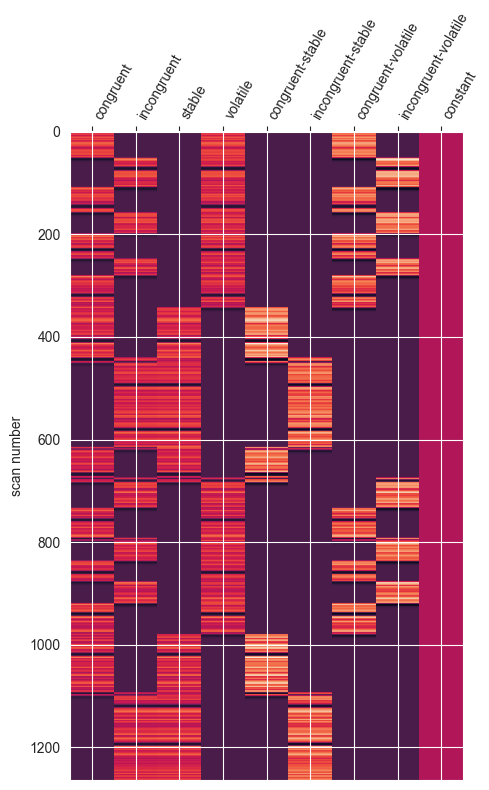

                      congruent  incongruent    stable  volatile  congruent-stable  incongruent-stable  congruent-volatile  incongruent-volatile  constant
congruent              1.000000    -0.789959  0.000267  0.216756          0.527695           -0.487166            0.669802             -0.466059 -0.015732
incongruent           -0.789959     1.000000  0.194489  0.015511         -0.427724            0.620366           -0.519617              0.586191 -0.489157
stable                 0.000267     0.194489  1.000000 -0.782740          0.558310            0.642364           -0.487750             -0.424904 -0.030608
volatile               0.216756     0.015511 -0.782740  1.000000         -0.442481           -0.497751            0.631969              0.533195 -0.476681
congruent-stable       0.527695    -0.427724  0.558310 -0.442481          1.000000           -0.277191           -0.277287             -0.238491  0.166045
incongruent-stable    -0.487166     0.620366  0.642364 -0.497751      

/Users/kenneth.van.der.zee/Documents/phd_1_analysis/venv/lib/python3.10/site-packages/nilearn/glm/_utils.py:180: UserWarning: Matrix is singular at working precision, regularizing...
  warn("Matrix is singular at working precision, regularizing...")


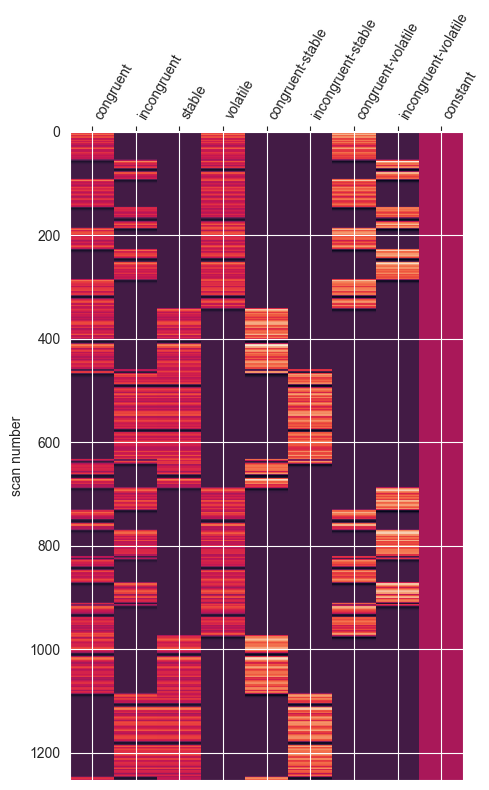

                      congruent  incongruent    stable  volatile  congruent-stable  incongruent-stable  congruent-volatile  incongruent-volatile  constant
congruent              1.000000    -0.784844  0.035934  0.195888          0.555467           -0.495064            0.637659             -0.460290 -0.078581
incongruent           -0.784844     1.000000  0.184420  0.021643         -0.434354            0.636636           -0.501946              0.580289 -0.457029
stable                 0.035934     0.184420  1.000000 -0.777110          0.578541            0.614510           -0.494543             -0.417963 -0.517782
volatile               0.195888     0.021643 -0.777110  1.000000         -0.448326           -0.478765            0.641028              0.532725 -0.024454
congruent-stable       0.555467    -0.434354  0.578541 -0.448326          1.000000           -0.287956           -0.286352             -0.239979 -0.200808
incongruent-stable    -0.495064     0.636636  0.614510 -0.478765      

/Users/kenneth.van.der.zee/Documents/phd_1_analysis/venv/lib/python3.10/site-packages/nilearn/glm/_utils.py:180: UserWarning: Matrix is singular at working precision, regularizing...
  warn("Matrix is singular at working precision, regularizing...")


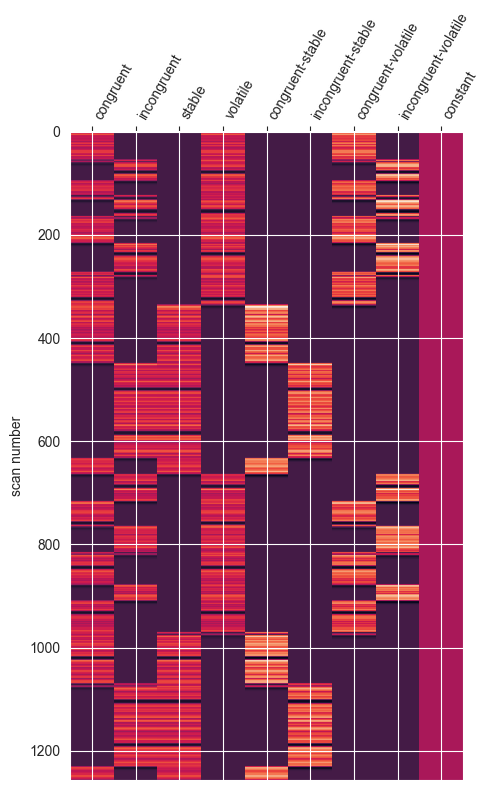

                      congruent  incongruent    stable  volatile  congruent-stable  incongruent-stable  congruent-volatile  incongruent-volatile  constant
congruent              1.000000    -0.778740  0.009896  0.194442          0.558343           -0.512098            0.629620             -0.437848 -0.116593
incongruent           -0.778740     1.000000  0.218842  0.023575         -0.420228            0.648074           -0.503961              0.572506 -0.212447
stable                 0.009896     0.218842  1.000000 -0.774249          0.563455            0.632308           -0.516252             -0.402756  0.044784
volatile               0.194442     0.023575 -0.774249  1.000000         -0.439177           -0.486823            0.635368              0.554050 -0.379879
congruent-stable       0.558343    -0.420228  0.563455 -0.439177          1.000000           -0.283753           -0.292983             -0.228294  0.082348
incongruent-stable    -0.512098     0.648074  0.632308 -0.486823      

/Users/kenneth.van.der.zee/Documents/phd_1_analysis/venv/lib/python3.10/site-packages/nilearn/glm/_utils.py:180: UserWarning: Matrix is singular at working precision, regularizing...
  warn("Matrix is singular at working precision, regularizing...")


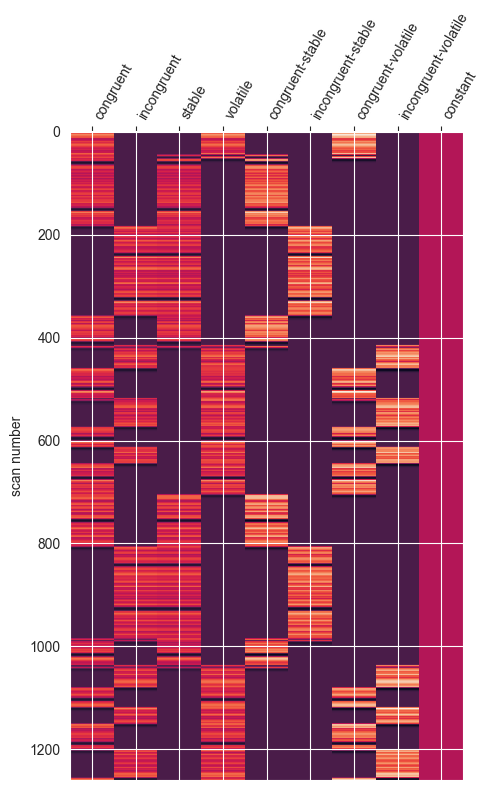

                      congruent  incongruent    stable  volatile  congruent-stable  incongruent-stable  congruent-volatile  incongruent-volatile  constant
congruent              1.000000    -0.780469  0.102072  0.140422          0.617192           -0.496503            0.588996             -0.441562 -0.232852
incongruent           -0.780469     1.000000  0.135918  0.068145         -0.482255            0.638969           -0.459122              0.562746  0.001065
stable                 0.102072     0.135918  1.000000 -0.772586          0.581088            0.584563           -0.472010             -0.458366 -0.166690
volatile               0.140422     0.068145 -0.772586  1.000000         -0.440481           -0.460059            0.624142              0.579527 -0.070869
congruent-stable       0.617192    -0.482255  0.581088 -0.440481          1.000000           -0.320626           -0.272328             -0.257976 -0.103593
incongruent-stable    -0.496503     0.638969  0.584563 -0.460059      

/Users/kenneth.van.der.zee/Documents/phd_1_analysis/venv/lib/python3.10/site-packages/nilearn/glm/_utils.py:180: UserWarning: Matrix is singular at working precision, regularizing...
  warn("Matrix is singular at working precision, regularizing...")


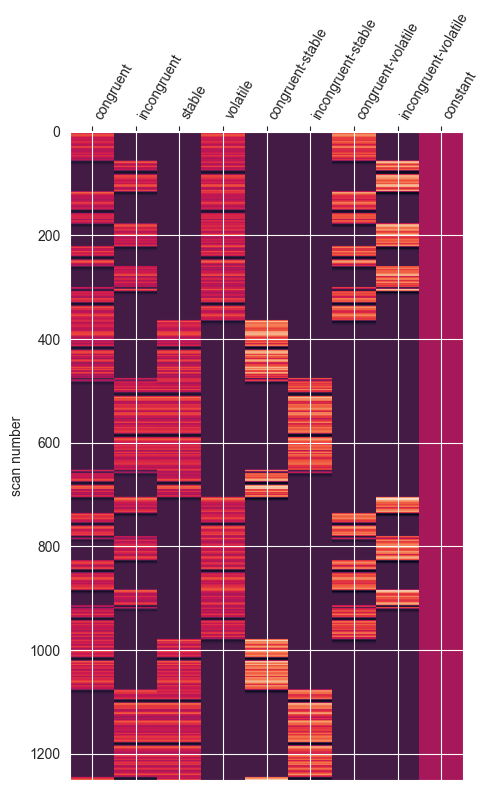

                      congruent  incongruent    stable  volatile  congruent-stable  incongruent-stable  congruent-volatile  incongruent-volatile  constant
congruent              1.000000    -0.780689 -0.009613  0.241480          0.533746           -0.494078            0.662572             -0.453129 -0.217948
incongruent           -0.780689     1.000000  0.252019 -0.039921         -0.412239            0.663637           -0.521205              0.545968  0.039593
stable                -0.009613     0.252019  1.000000 -0.775046          0.550322            0.655079           -0.498341             -0.408765 -0.360797
volatile               0.241480    -0.039921 -0.775046  1.000000         -0.434453           -0.500542            0.658957              0.509130  0.185133
congruent-stable       0.533746    -0.412239  0.550322 -0.434453          1.000000           -0.270352           -0.279742             -0.228681 -0.313574
incongruent-stable    -0.494078     0.663637  0.655079 -0.500542      

/Users/kenneth.van.der.zee/Documents/phd_1_analysis/venv/lib/python3.10/site-packages/nilearn/glm/_utils.py:180: UserWarning: Matrix is singular at working precision, regularizing...
  warn("Matrix is singular at working precision, regularizing...")


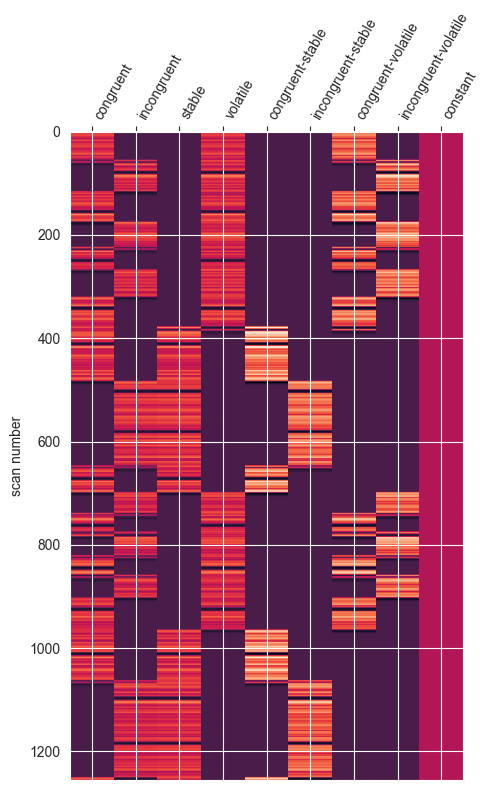

                      congruent  incongruent    stable  volatile  congruent-stable  incongruent-stable  congruent-volatile  incongruent-volatile  constant
congruent              1.000000    -0.784517  0.025665  0.184306          0.561999           -0.477573            0.650845             -0.452706 -0.116769
incongruent           -0.784517     1.000000  0.200184  0.022660         -0.432303            0.620971           -0.518488              0.564176 -0.056599
stable                 0.025665     0.200184  1.000000 -0.782584          0.549738            0.657060           -0.474649             -0.448237 -0.475576
volatile               0.184306     0.022660 -0.782584  1.000000         -0.429165           -0.515153            0.608949              0.570245  0.306135
congruent-stable       0.561999    -0.432303  0.549738 -0.429165          1.000000           -0.268498           -0.262197             -0.243841 -0.319092
incongruent-stable    -0.477573     0.620971  0.657060 -0.515153      

/Users/kenneth.van.der.zee/Documents/phd_1_analysis/venv/lib/python3.10/site-packages/nilearn/glm/_utils.py:180: UserWarning: Matrix is singular at working precision, regularizing...
  warn("Matrix is singular at working precision, regularizing...")


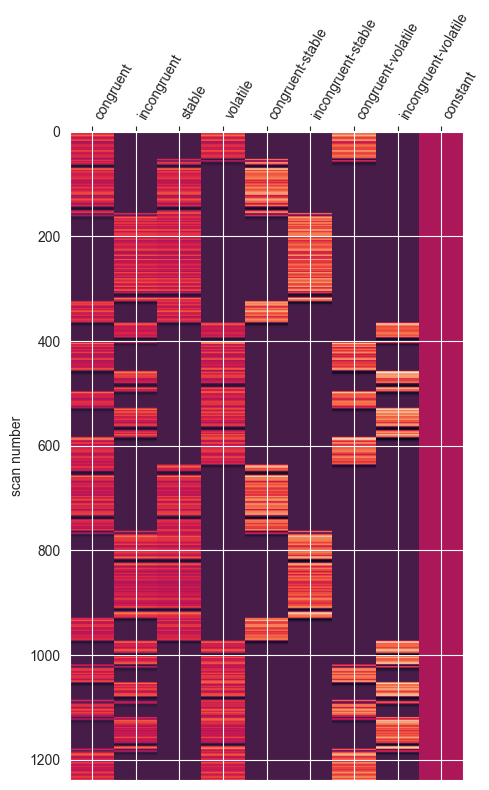

                      congruent  incongruent    stable  volatile  congruent-stable  incongruent-stable  congruent-volatile  incongruent-volatile  constant
congruent              1.000000    -0.792086  0.068950  0.161414          0.584719           -0.513711            0.598848             -0.451289 -0.081158
incongruent           -0.792086     1.000000  0.144674  0.043367         -0.456995            0.638856           -0.480412              0.580019 -0.449864
stable                 0.068950     0.144674  1.000000 -0.789246          0.602419            0.581201           -0.513625             -0.433627 -0.297200
volatile               0.161414     0.043367 -0.789246  1.000000         -0.463677           -0.470720            0.647586              0.552912 -0.232696
congruent-stable       0.584719    -0.456995  0.602419 -0.463677          1.000000           -0.299401           -0.299531             -0.257181 -0.064433
incongruent-stable    -0.513711     0.638856  0.581201 -0.470720      

/Users/kenneth.van.der.zee/Documents/phd_1_analysis/venv/lib/python3.10/site-packages/nilearn/glm/_utils.py:180: UserWarning: Matrix is singular at working precision, regularizing...
  warn("Matrix is singular at working precision, regularizing...")


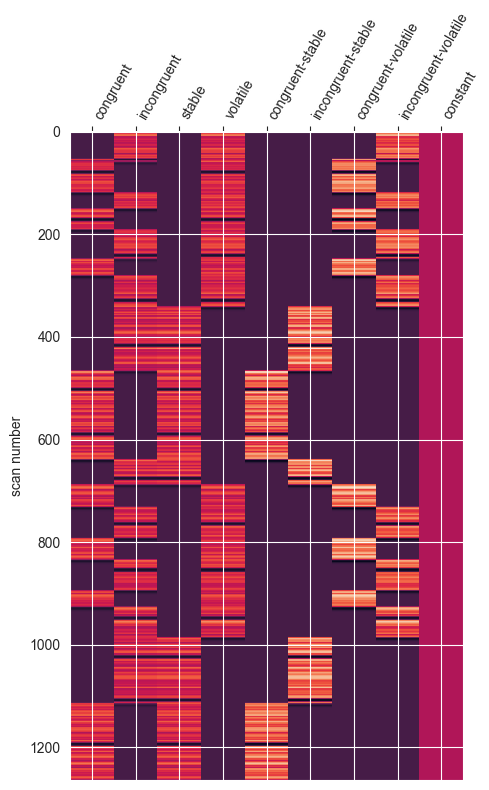

                      congruent  incongruent    stable  volatile  congruent-stable  incongruent-stable  congruent-volatile  incongruent-volatile  constant
congruent              1.000000    -0.780722  0.223107 -0.032641          0.665678           -0.419478            0.559036             -0.504169 -0.269106
incongruent           -0.780722     1.000000  0.010747  0.243493         -0.497193            0.530690           -0.461469              0.651683  0.187545
stable                 0.223107     0.010747  1.000000 -0.773928          0.621381            0.578701           -0.400672             -0.505775 -0.394222
volatile              -0.032641     0.243493 -0.773928  1.000000         -0.475247           -0.453761            0.485654              0.680393  0.322417
congruent-stable       0.665678    -0.497193  0.621381 -0.475247          1.000000           -0.279389           -0.246602             -0.310111 -0.389386
incongruent-stable    -0.419478     0.530690  0.578701 -0.453761      

/Users/kenneth.van.der.zee/Documents/phd_1_analysis/venv/lib/python3.10/site-packages/nilearn/glm/_utils.py:180: UserWarning: Matrix is singular at working precision, regularizing...
  warn("Matrix is singular at working precision, regularizing...")


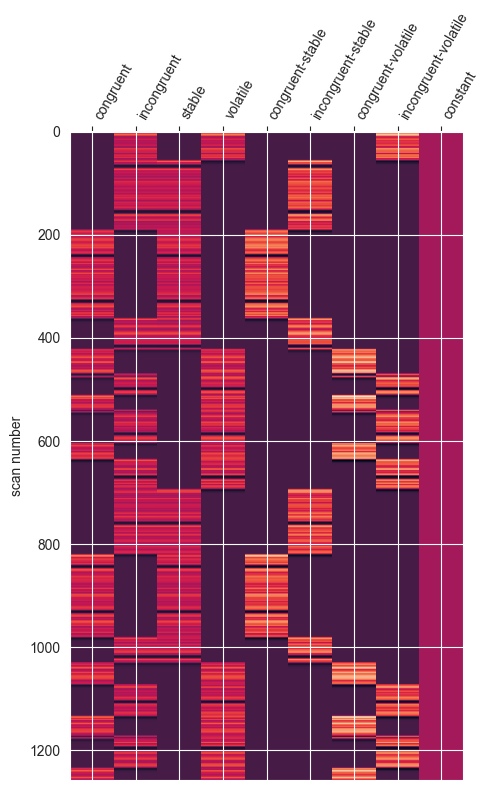

                      congruent  incongruent    stable  volatile  congruent-stable  incongruent-stable  congruent-volatile  incongruent-volatile  constant
congruent              1.000000    -0.778530  0.165070  0.051714          0.671826           -0.474088            0.558342             -0.440814  0.264575
incongruent           -0.778530     1.000000  0.071533  0.160954         -0.519455            0.596160           -0.438698              0.579202 -0.666353
stable                 0.165070     0.071533  1.000000 -0.772040          0.573184            0.585955           -0.425605             -0.510214 -0.510941
volatile               0.051714     0.160954 -0.772040  1.000000         -0.430033           -0.464732            0.549434              0.662513  0.103586
congruent-stable       0.671826    -0.519455  0.573184 -0.430033          1.000000           -0.328156           -0.239392             -0.282108 -0.111166
incongruent-stable    -0.474088     0.596160  0.585955 -0.464732      

/Users/kenneth.van.der.zee/Documents/phd_1_analysis/venv/lib/python3.10/site-packages/nilearn/glm/_utils.py:180: UserWarning: Matrix is singular at working precision, regularizing...
  warn("Matrix is singular at working precision, regularizing...")


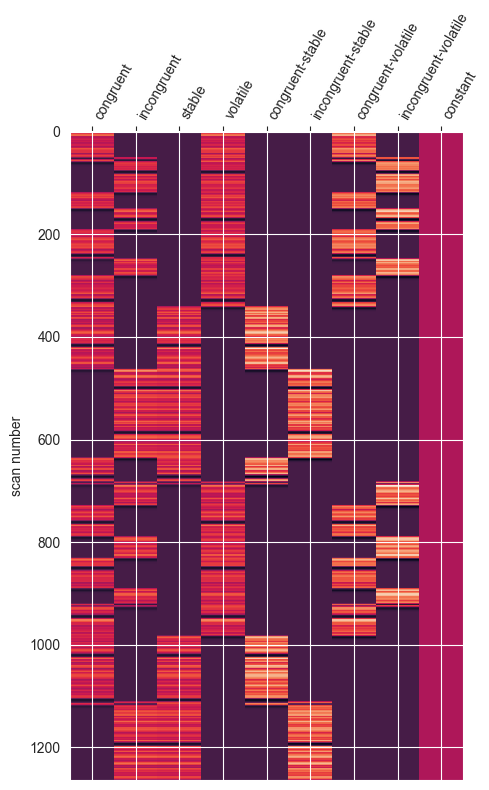

                      congruent  incongruent    stable  volatile  congruent-stable  incongruent-stable  congruent-volatile  incongruent-volatile  constant
congruent              1.000000    -0.779419  0.009635  0.244468          0.530790           -0.498722            0.650475             -0.457457 -0.062620
incongruent           -0.779419     1.000000  0.224749 -0.032258         -0.416785            0.665250           -0.504235              0.558721 -0.347197
stable                 0.009635     0.224749  1.000000 -0.773393          0.579069            0.621449           -0.508108             -0.398660  0.062671
volatile               0.244468    -0.032258 -0.773393  1.000000         -0.451886           -0.476743            0.680290              0.487711 -0.475001
congruent-stable       0.530790    -0.416785  0.579069 -0.451886          1.000000           -0.278872           -0.298437             -0.231083  0.214294
incongruent-stable    -0.498722     0.665250  0.621449 -0.476743      

/Users/kenneth.van.der.zee/Documents/phd_1_analysis/venv/lib/python3.10/site-packages/nilearn/glm/_utils.py:180: UserWarning: Matrix is singular at working precision, regularizing...
  warn("Matrix is singular at working precision, regularizing...")


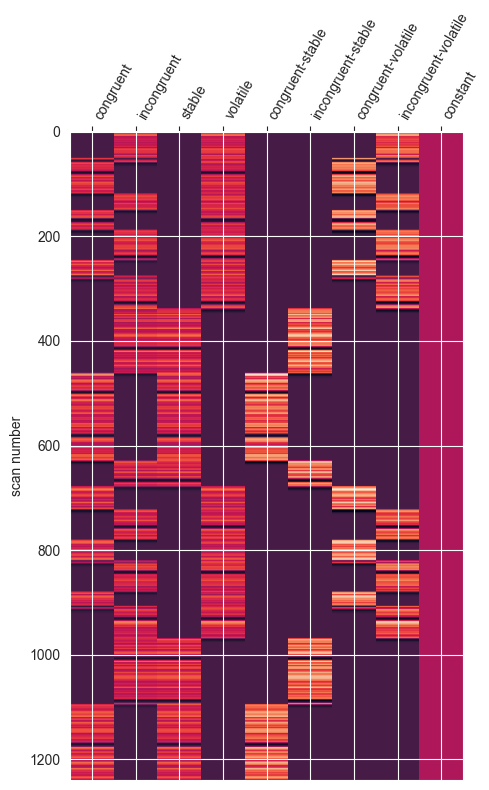

                      congruent  incongruent    stable  volatile  congruent-stable  incongruent-stable  congruent-volatile  incongruent-volatile  constant
congruent              1.000000    -0.776202  0.220015 -0.025617          0.666327           -0.420036            0.558477             -0.495745  0.385981
incongruent           -0.776202     1.000000  0.012917  0.243628         -0.499528            0.532255           -0.453155              0.646688 -0.580297
stable                 0.220015     0.012917  1.000000 -0.772292          0.618321            0.582850           -0.401898             -0.510588  0.205678
volatile              -0.025617     0.243628 -0.772292  1.000000         -0.472458           -0.455370            0.492298              0.684662 -0.419318
congruent-stable       0.666327    -0.499528  0.618321 -0.472458          1.000000           -0.278238           -0.246411             -0.311901  0.406688
incongruent-stable    -0.420036     0.532255  0.582850 -0.455370      

/Users/kenneth.van.der.zee/Documents/phd_1_analysis/venv/lib/python3.10/site-packages/nilearn/glm/_utils.py:180: UserWarning: Matrix is singular at working precision, regularizing...
  warn("Matrix is singular at working precision, regularizing...")


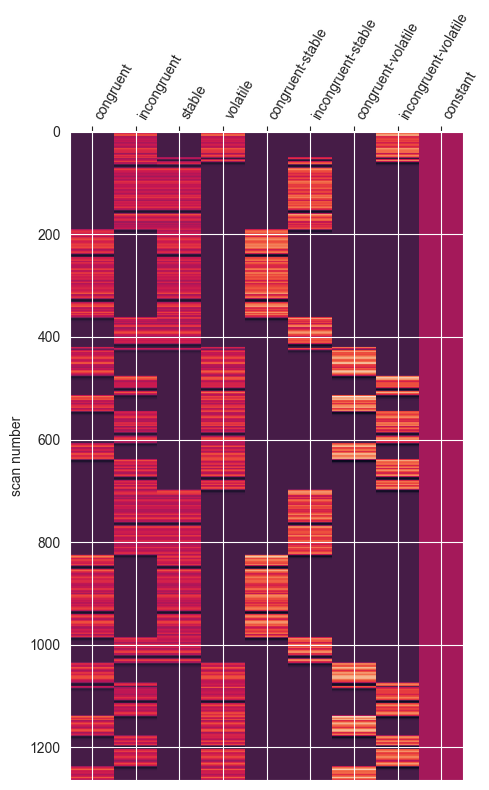

                      congruent  incongruent    stable  volatile  congruent-stable  incongruent-stable  congruent-volatile  incongruent-volatile  constant
congruent              1.000000    -0.782024  0.165296  0.047037          0.668541           -0.472290            0.562522             -0.450175 -0.187603
incongruent           -0.782024     1.000000  0.069852  0.162672         -0.515343            0.591996           -0.448212              0.587637 -0.084427
stable                 0.165296     0.069852  1.000000 -0.772883          0.575460            0.584501           -0.423929             -0.504248 -0.189497
volatile               0.047037     0.162672 -0.772883  1.000000         -0.432352           -0.464065            0.542088              0.658173 -0.086940
congruent-stable       0.668541    -0.515343  0.575460 -0.432352          1.000000           -0.327224           -0.238789             -0.280605 -0.228186
incongruent-stable    -0.472290     0.591996  0.584501 -0.464065      

/Users/kenneth.van.der.zee/Documents/phd_1_analysis/venv/lib/python3.10/site-packages/nilearn/glm/_utils.py:180: UserWarning: Matrix is singular at working precision, regularizing...
  warn("Matrix is singular at working precision, regularizing...")


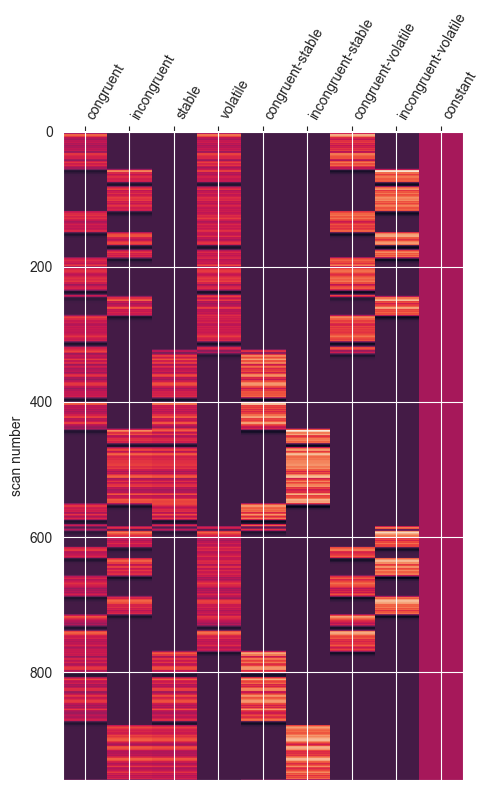

                      congruent  incongruent    stable  volatile  congruent-stable  incongruent-stable  congruent-volatile  incongruent-volatile  constant
congruent              1.000000    -0.790849  0.077603  0.180573          0.528043           -0.472282            0.632375             -0.513595 -0.400574
incongruent           -0.790849     1.000000  0.133046  0.034788         -0.416958            0.617677           -0.500702              0.629169  0.140762
stable                 0.077603     0.133046  1.000000 -0.781917          0.644166            0.564118           -0.501159             -0.392615  0.198254
volatile               0.180573     0.034788 -0.781917  1.000000         -0.503856           -0.440909            0.660790              0.478896 -0.474730
congruent-stable       0.528043    -0.416958  0.644166 -0.503856          1.000000           -0.268176           -0.323935             -0.251830 -0.163054
incongruent-stable    -0.472282     0.617677  0.564118 -0.440909      

/Users/kenneth.van.der.zee/Documents/phd_1_analysis/venv/lib/python3.10/site-packages/nilearn/glm/_utils.py:180: UserWarning: Matrix is singular at working precision, regularizing...
  warn("Matrix is singular at working precision, regularizing...")


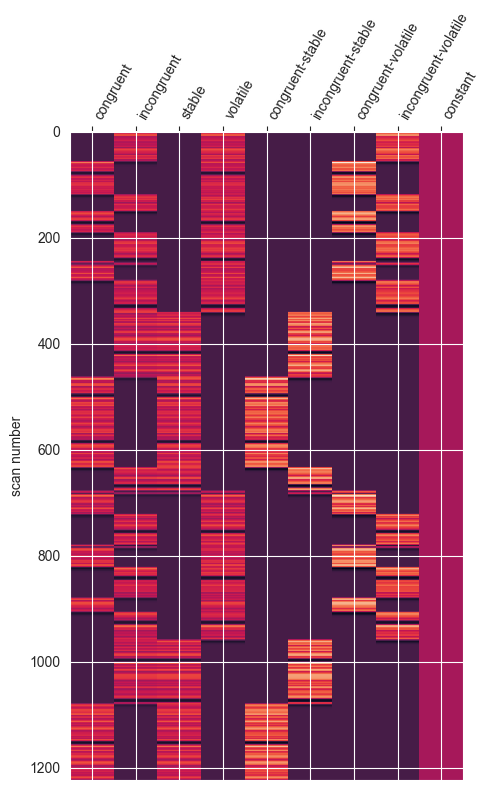

                      congruent  incongruent    stable  volatile  congruent-stable  incongruent-stable  congruent-volatile  incongruent-volatile  constant
congruent              1.000000    -0.775533  0.236093 -0.037120          0.669008           -0.411669            0.556441             -0.506072 -0.044748
incongruent           -0.775533     1.000000  0.004510  0.251997         -0.498183            0.528769           -0.454629              0.654375 -0.118093
stable                 0.236093     0.004510  1.000000 -0.768427          0.626492            0.574384           -0.392414             -0.506647 -0.514079
volatile              -0.037120     0.251997 -0.768427  1.000000         -0.476797           -0.446221            0.484596              0.681154  0.352107
congruent-stable       0.669008    -0.498183  0.626492 -0.476797          1.000000           -0.278182           -0.245297             -0.312851 -0.276997
incongruent-stable    -0.411669     0.528769  0.574384 -0.446221      

/Users/kenneth.van.der.zee/Documents/phd_1_analysis/venv/lib/python3.10/site-packages/nilearn/glm/_utils.py:180: UserWarning: Matrix is singular at working precision, regularizing...
  warn("Matrix is singular at working precision, regularizing...")


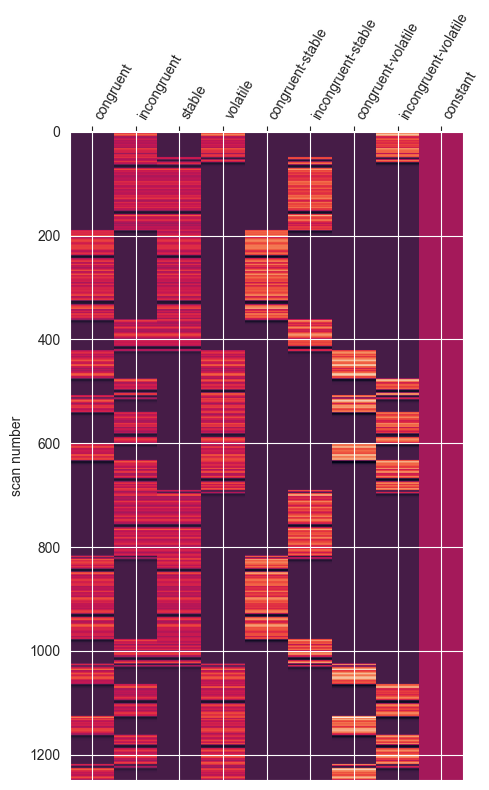

                      congruent  incongruent    stable  volatile  congruent-stable  incongruent-stable  congruent-volatile  incongruent-volatile  constant
congruent              1.000000    -0.777174  0.175170  0.037399          0.676774           -0.469495            0.554863             -0.446716  0.051593
incongruent           -0.777174     1.000000  0.066893  0.173805         -0.517339            0.591377           -0.440980              0.587568 -0.431415
stable                 0.175170     0.066893  1.000000 -0.769260          0.577042            0.584590           -0.420928             -0.507606 -0.289451
volatile               0.037399     0.173805 -0.769260  1.000000         -0.431995           -0.461523            0.537536              0.668375 -0.099031
congruent-stable       0.676774    -0.517339  0.577042 -0.431995          1.000000           -0.325292           -0.236951             -0.284555 -0.024575
incongruent-stable    -0.469495     0.591377  0.584590 -0.461523      

/Users/kenneth.van.der.zee/Documents/phd_1_analysis/venv/lib/python3.10/site-packages/nilearn/glm/_utils.py:180: UserWarning: Matrix is singular at working precision, regularizing...
  warn("Matrix is singular at working precision, regularizing...")


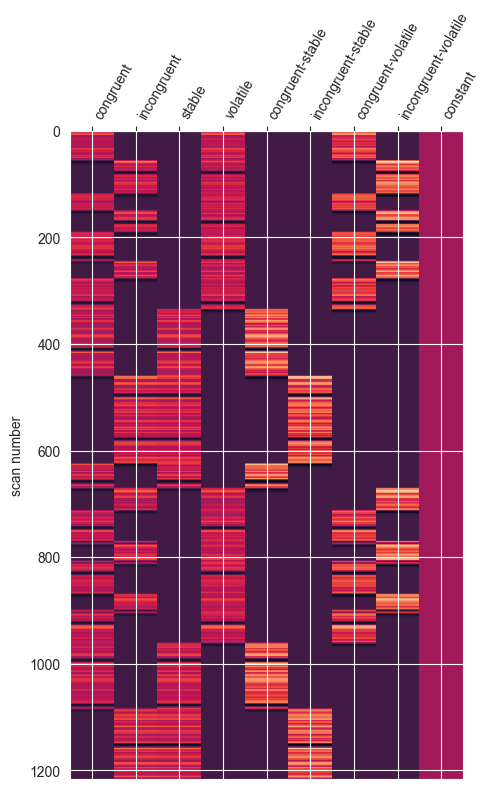

                      congruent  incongruent    stable  volatile  congruent-stable  incongruent-stable  congruent-volatile  incongruent-volatile  constant
congruent              1.000000    -0.773402  0.020417  0.238036          0.528992           -0.491769            0.646663             -0.462254 -0.074041
incongruent           -0.773402     1.000000  0.218094 -0.019256         -0.413356            0.663225           -0.496326              0.567578 -0.324108
stable                 0.020417     0.218094  1.000000 -0.768767          0.590120            0.616127           -0.507510             -0.394881  0.144906
volatile               0.238036    -0.019256 -0.768767  1.000000         -0.461717           -0.465802            0.682117              0.487439 -0.545056
congruent-stable       0.528992    -0.413356  0.590120 -0.461717          1.000000           -0.272291           -0.305233             -0.236655  0.252648
incongruent-stable    -0.491769     0.663225  0.616127 -0.465802      

/Users/kenneth.van.der.zee/Documents/phd_1_analysis/venv/lib/python3.10/site-packages/nilearn/glm/_utils.py:180: UserWarning: Matrix is singular at working precision, regularizing...
  warn("Matrix is singular at working precision, regularizing...")


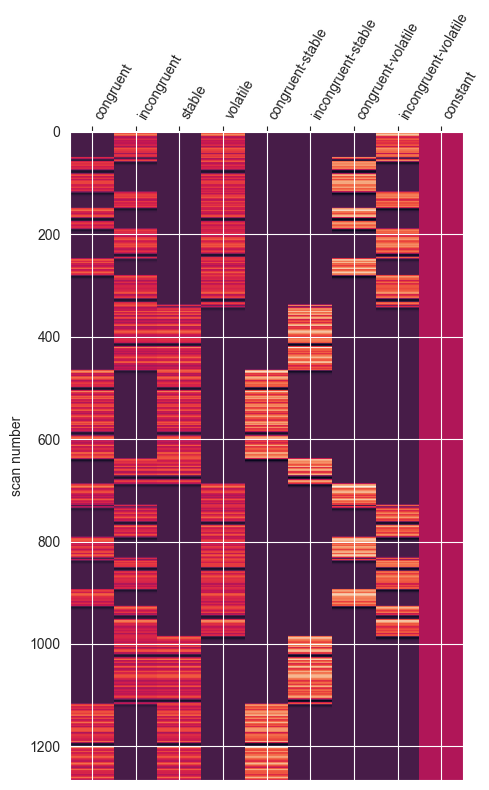

                      congruent  incongruent    stable  volatile  congruent-stable  incongruent-stable  congruent-volatile  incongruent-volatile  constant
congruent              1.000000    -0.778969  0.221960 -0.029968          0.668221           -0.423073            0.555647             -0.499817 -0.305586
incongruent           -0.778969     1.000000  0.014603  0.240794         -0.499327            0.536928           -0.456520              0.647233  0.200533
stable                 0.221960     0.014603  1.000000 -0.773000          0.620158            0.578783           -0.403974             -0.506445 -0.495551
volatile              -0.029968     0.240794 -0.773000  1.000000         -0.474709           -0.452257            0.491482              0.681328  0.402401
congruent-stable       0.668221    -0.499327  0.620158 -0.474709          1.000000           -0.280790           -0.247249             -0.311717 -0.449152
incongruent-stable    -0.423073     0.536928  0.578783 -0.452257      

/Users/kenneth.van.der.zee/Documents/phd_1_analysis/venv/lib/python3.10/site-packages/nilearn/glm/_utils.py:180: UserWarning: Matrix is singular at working precision, regularizing...
  warn("Matrix is singular at working precision, regularizing...")


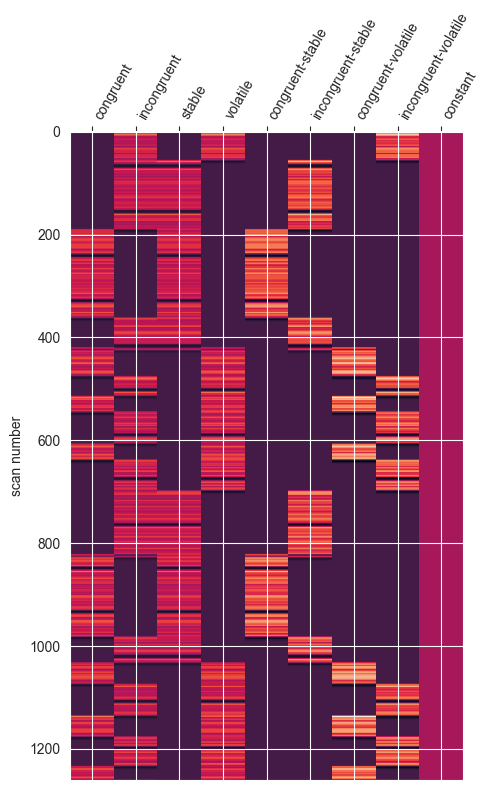

                      congruent  incongruent    stable  volatile  congruent-stable  incongruent-stable  congruent-volatile  incongruent-volatile  constant
congruent              1.000000    -0.780435  0.158566  0.052111          0.661582           -0.467697            0.568271             -0.451453  0.192615
incongruent           -0.780435     1.000000  0.078564  0.157024         -0.506909            0.590113           -0.453827              0.587648 -0.377444
stable                 0.158566     0.078564  1.000000 -0.773051          0.574891            0.592428           -0.425612             -0.501113 -0.218771
volatile               0.052111     0.157024 -0.773051  1.000000         -0.433082           -0.469140            0.542668              0.655326  0.028991
congruent-stable       0.661582    -0.506909  0.574891 -0.433082          1.000000           -0.318604           -0.241068             -0.278371 -0.006551
incongruent-stable    -0.467697     0.590113  0.592428 -0.469140      

/Users/kenneth.van.der.zee/Documents/phd_1_analysis/venv/lib/python3.10/site-packages/nilearn/glm/_utils.py:180: UserWarning: Matrix is singular at working precision, regularizing...
  warn("Matrix is singular at working precision, regularizing...")


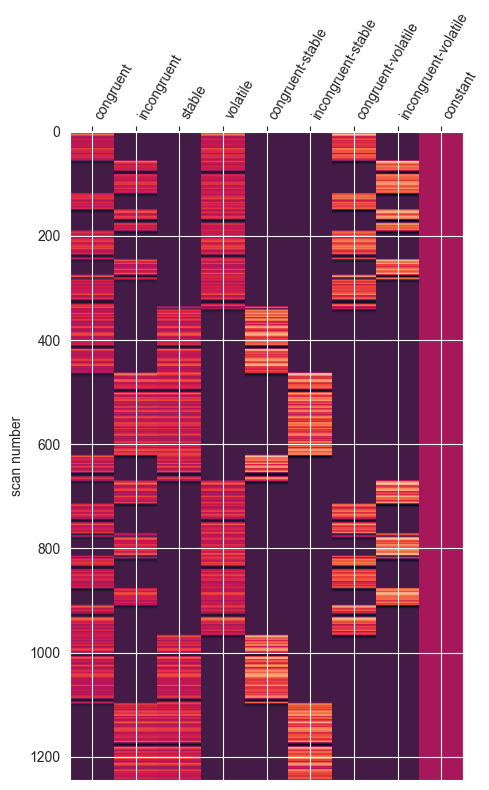

                      congruent  incongruent    stable  volatile  congruent-stable  incongruent-stable  congruent-volatile  incongruent-volatile  constant
congruent              1.000000    -0.787130  0.023034  0.224268          0.539057           -0.500603            0.642168             -0.465503 -0.105418
incongruent           -0.787130     1.000000  0.201547 -0.017437         -0.426714            0.656955           -0.503281              0.568512 -0.182498
stable                 0.023034     0.201547  1.000000 -0.780846          0.587960            0.610284           -0.509021             -0.406869  0.192260
volatile               0.224268    -0.017437 -0.780846  1.000000         -0.460525           -0.475149            0.673176              0.496061 -0.484748
congruent-stable       0.539057    -0.426714  0.587960 -0.460525          1.000000           -0.281966           -0.299488             -0.240808  0.155485
incongruent-stable    -0.500603     0.656955  0.610284 -0.475149      

/Users/kenneth.van.der.zee/Documents/phd_1_analysis/venv/lib/python3.10/site-packages/nilearn/glm/_utils.py:180: UserWarning: Matrix is singular at working precision, regularizing...
  warn("Matrix is singular at working precision, regularizing...")


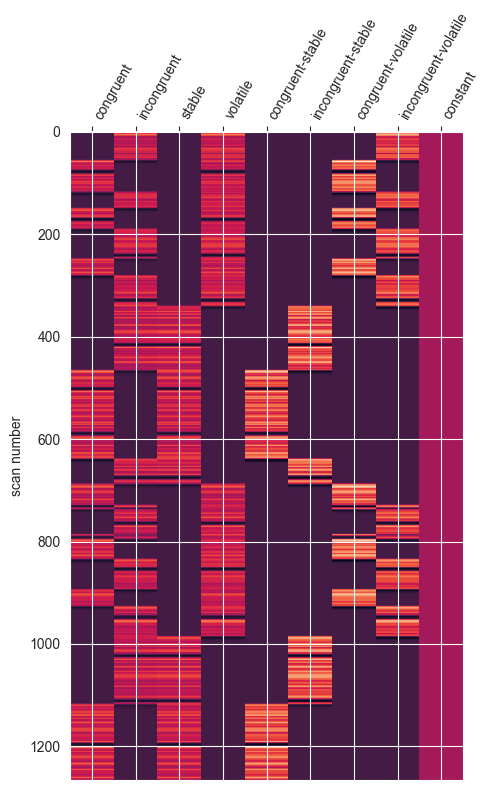

                      congruent  incongruent    stable  volatile  congruent-stable  incongruent-stable  congruent-volatile  incongruent-volatile  constant
congruent              1.000000    -0.780376  0.220627 -0.026451          0.664804           -0.420345            0.561276             -0.501762  0.154499
incongruent           -0.780376     1.000000  0.012215  0.238771         -0.498460            0.532403           -0.460538              0.648586 -0.456961
stable                 0.220627     0.012215  1.000000 -0.773944          0.619602            0.579680           -0.400129             -0.507463 -0.616178
volatile              -0.026451     0.238771 -0.773944  1.000000         -0.473113           -0.455309            0.489838              0.678569  0.303639
congruent-stable       0.664804    -0.498460  0.619602 -0.473113          1.000000           -0.280413           -0.245116             -0.309778 -0.216502
incongruent-stable    -0.420345     0.532403  0.579680 -0.455309      

/Users/kenneth.van.der.zee/Documents/phd_1_analysis/venv/lib/python3.10/site-packages/nilearn/glm/_utils.py:180: UserWarning: Matrix is singular at working precision, regularizing...
  warn("Matrix is singular at working precision, regularizing...")


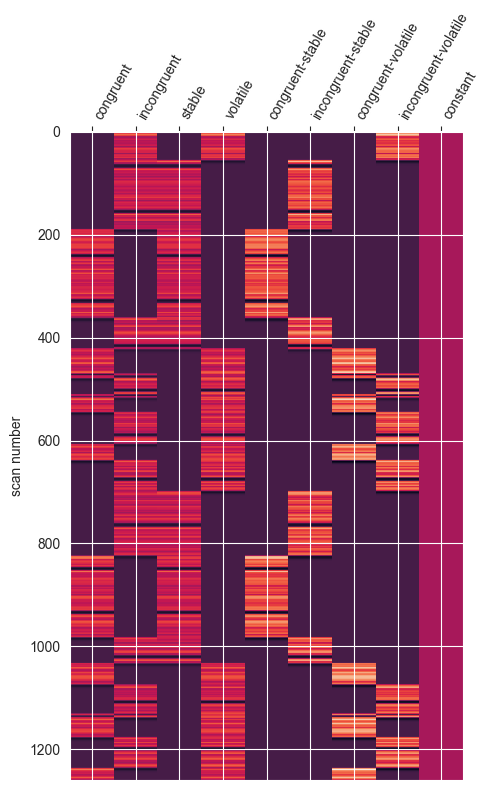

                      congruent  incongruent    stable  volatile  congruent-stable  incongruent-stable  congruent-volatile  incongruent-volatile  constant
congruent              1.000000    -0.779652  0.162386  0.048943          0.670023           -0.473686            0.559894             -0.442741 -0.432521
incongruent           -0.779652     1.000000  0.072625  0.163063         -0.515483            0.592343           -0.444226              0.583212  0.334914
stable                 0.162386     0.072625  1.000000 -0.773134          0.572959            0.588393           -0.427150             -0.507509  0.090506
volatile               0.048943     0.163063 -0.773134  1.000000         -0.430072           -0.467636            0.544030              0.663971 -0.186284
congruent-stable       0.670023    -0.515483  0.572959 -0.430072          1.000000           -0.325571           -0.239935             -0.280241 -0.147932
incongruent-stable    -0.473686     0.592343  0.588393 -0.467636      

/Users/kenneth.van.der.zee/Documents/phd_1_analysis/venv/lib/python3.10/site-packages/nilearn/glm/_utils.py:180: UserWarning: Matrix is singular at working precision, regularizing...
  warn("Matrix is singular at working precision, regularizing...")


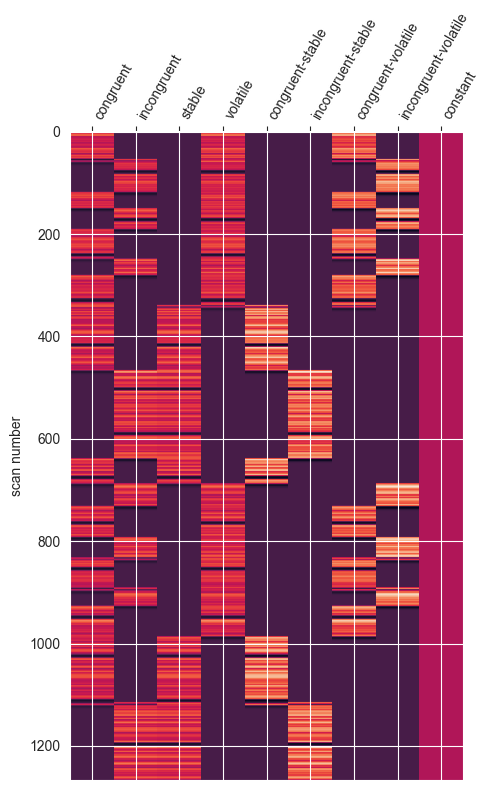

                      congruent  incongruent    stable  volatile  congruent-stable  incongruent-stable  congruent-volatile  incongruent-volatile  constant
congruent              1.000000    -0.779087  0.016715  0.237516          0.539068           -0.500201            0.644876             -0.455454  0.259948
incongruent           -0.779087     1.000000  0.220606 -0.028108         -0.421815            0.666962           -0.500750              0.556809 -0.420751
stable                 0.016715     0.220606  1.000000 -0.773563          0.580628            0.619198           -0.507919             -0.403427  0.321231
volatile               0.237516    -0.028108 -0.773563  1.000000         -0.452043           -0.476200            0.679546              0.494326 -0.477187
congruent-stable       0.539068    -0.421815  0.580628 -0.452043          1.000000           -0.279790           -0.296098             -0.236593  0.469733
incongruent-stable    -0.500201     0.666962  0.619198 -0.476200      

/Users/kenneth.van.der.zee/Documents/phd_1_analysis/venv/lib/python3.10/site-packages/nilearn/glm/_utils.py:180: UserWarning: Matrix is singular at working precision, regularizing...
  warn("Matrix is singular at working precision, regularizing...")


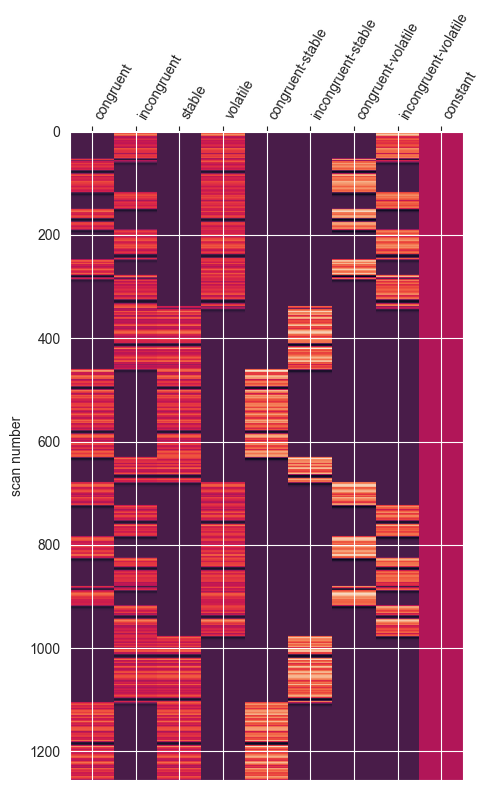

                      congruent  incongruent    stable  volatile  congruent-stable  incongruent-stable  congruent-volatile  incongruent-volatile  constant
congruent              1.000000    -0.778796  0.224946 -0.032789          0.663873           -0.417081            0.560244             -0.507514  0.167273
incongruent           -0.778796     1.000000  0.011362  0.245708         -0.495712            0.532017           -0.459920              0.654815 -0.447270
stable                 0.224946     0.011362  1.000000 -0.771300          0.624346            0.577581           -0.400106             -0.502709 -0.005597
volatile              -0.032789     0.245708 -0.771300  1.000000         -0.478722           -0.448452            0.487761              0.677859 -0.290844
congruent-stable       0.663873    -0.495712  0.624346 -0.478722          1.000000           -0.277066           -0.247530             -0.312693  0.153338
incongruent-stable    -0.417081     0.532017  0.577581 -0.448452      

/Users/kenneth.van.der.zee/Documents/phd_1_analysis/venv/lib/python3.10/site-packages/nilearn/glm/_utils.py:180: UserWarning: Matrix is singular at working precision, regularizing...
  warn("Matrix is singular at working precision, regularizing...")


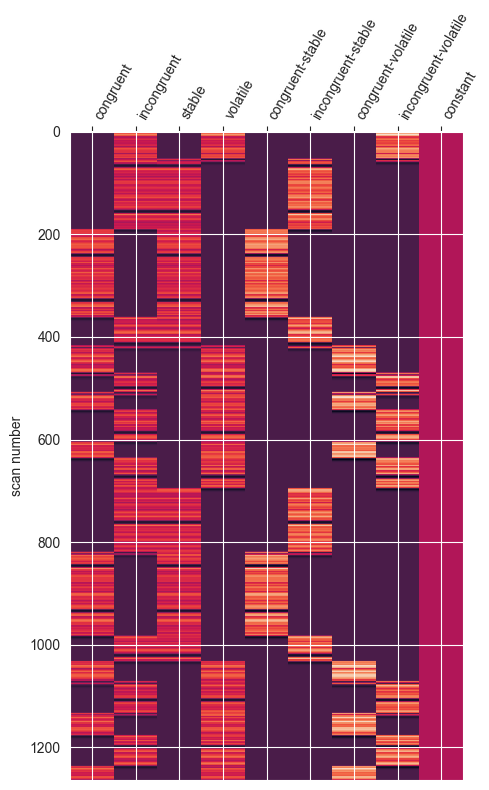

                      congruent  incongruent    stable  volatile  congruent-stable  incongruent-stable  congruent-volatile  incongruent-volatile  constant
congruent              1.000000    -0.776639  0.164624  0.047942          0.667711           -0.472500            0.557535             -0.443625  0.041609
incongruent           -0.776639     1.000000  0.070995  0.167764         -0.512144            0.591875           -0.440169              0.587788 -0.371279
stable                 0.164624     0.070995  1.000000 -0.771868          0.580065            0.586382           -0.432505             -0.504648 -0.237205
volatile               0.047942     0.167764 -0.771868  1.000000         -0.436524           -0.463756            0.549225              0.663745 -0.098121
congruent-stable       0.667711    -0.512144  0.580065 -0.436524          1.000000           -0.319691           -0.245711             -0.284405 -0.038706
incongruent-stable    -0.472500     0.591875  0.586382 -0.463756      

/Users/kenneth.van.der.zee/Documents/phd_1_analysis/venv/lib/python3.10/site-packages/nilearn/glm/_utils.py:180: UserWarning: Matrix is singular at working precision, regularizing...
  warn("Matrix is singular at working precision, regularizing...")


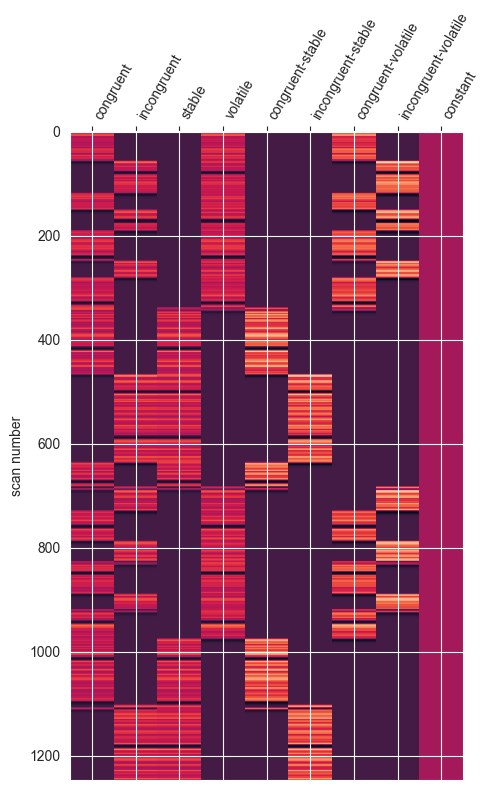

                      congruent  incongruent    stable  volatile  congruent-stable  incongruent-stable  congruent-volatile  incongruent-volatile  constant
congruent              1.000000    -0.777705  0.022223  0.229882          0.539312           -0.496136            0.644658             -0.459261 -0.217663
incongruent           -0.777705     1.000000  0.213052 -0.014072         -0.421903            0.660100           -0.499104              0.566228 -0.222021
stable                 0.022223     0.213052  1.000000 -0.770740          0.582212            0.616329           -0.503331             -0.401330  0.114986
volatile               0.229882    -0.014072 -0.770740  1.000000         -0.453088           -0.470813            0.672061              0.498451 -0.563683
congruent-stable       0.539312    -0.421903  0.582212 -0.453088          1.000000           -0.281423           -0.296095             -0.235685  0.070374
incongruent-stable    -0.496136     0.660100  0.616329 -0.470813      

/Users/kenneth.van.der.zee/Documents/phd_1_analysis/venv/lib/python3.10/site-packages/nilearn/glm/_utils.py:180: UserWarning: Matrix is singular at working precision, regularizing...
  warn("Matrix is singular at working precision, regularizing...")


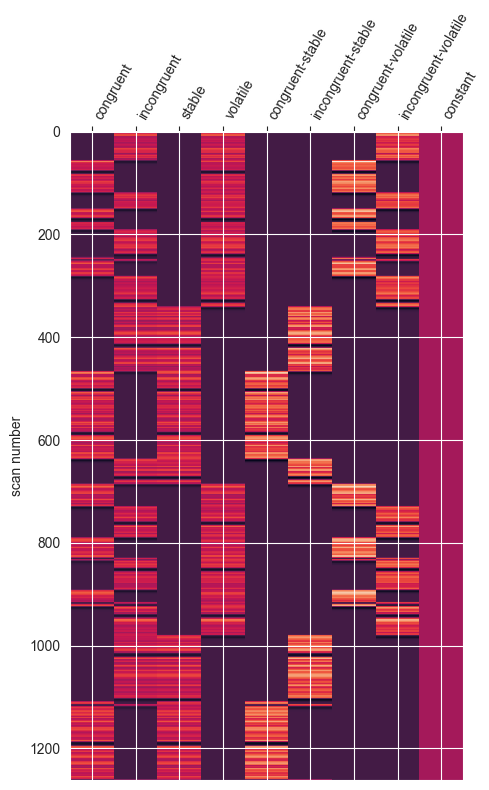

                      congruent  incongruent    stable  volatile  congruent-stable  incongruent-stable  congruent-volatile  incongruent-volatile  constant
congruent              1.000000    -0.780722  0.219834 -0.024535          0.665573           -0.420393            0.562383             -0.500575 -0.245665
incongruent           -0.780722     1.000000  0.012188  0.236936         -0.501142            0.533205           -0.459546              0.645918  0.091617
stable                 0.219834     0.012188  1.000000 -0.774386          0.617071            0.580975           -0.397928             -0.510528 -0.502147
volatile              -0.024535     0.236936 -0.774386  1.000000         -0.471477           -0.456493            0.490468              0.678977  0.354090
congruent-stable       0.665573    -0.501142  0.617071 -0.471477          1.000000           -0.281977           -0.242818             -0.310372 -0.407485
incongruent-stable    -0.420393     0.533205  0.580975 -0.456493      

/Users/kenneth.van.der.zee/Documents/phd_1_analysis/venv/lib/python3.10/site-packages/nilearn/glm/_utils.py:180: UserWarning: Matrix is singular at working precision, regularizing...
  warn("Matrix is singular at working precision, regularizing...")


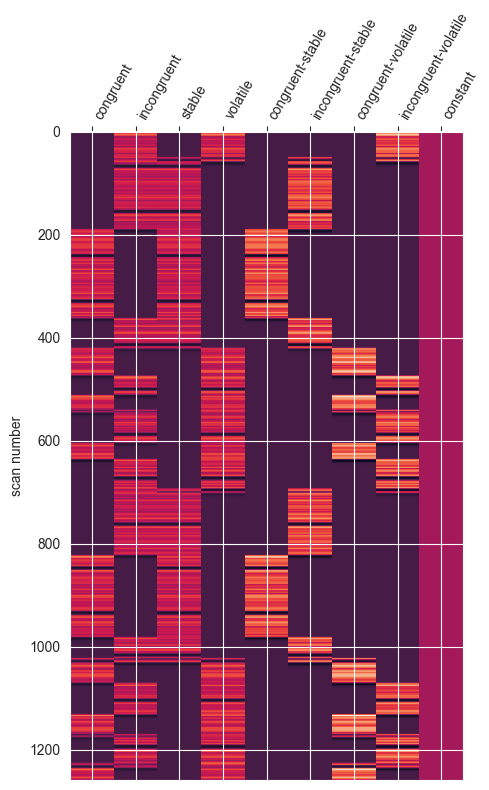

                      congruent  incongruent    stable  volatile  congruent-stable  incongruent-stable  congruent-volatile  incongruent-volatile  constant
congruent              1.000000    -0.779302  0.162870  0.056706          0.664182           -0.474993            0.565283             -0.446423 -0.147751
incongruent           -0.779302     1.000000  0.065270  0.164532         -0.515367            0.590974           -0.442988              0.591380  0.031421
stable                 0.162870     0.065270  1.000000 -0.771227          0.580172            0.580480           -0.428751             -0.503108  0.084740
volatile               0.056706     0.164532 -0.771227  1.000000         -0.433776           -0.461347            0.552259              0.655676 -0.203206
congruent-stable       0.664182    -0.515367  0.580172 -0.433776          1.000000           -0.326443           -0.241219             -0.282911  0.039970
incongruent-stable    -0.474993     0.590974  0.580480 -0.461347      

/Users/kenneth.van.der.zee/Documents/phd_1_analysis/venv/lib/python3.10/site-packages/nilearn/glm/_utils.py:180: UserWarning: Matrix is singular at working precision, regularizing...
  warn("Matrix is singular at working precision, regularizing...")


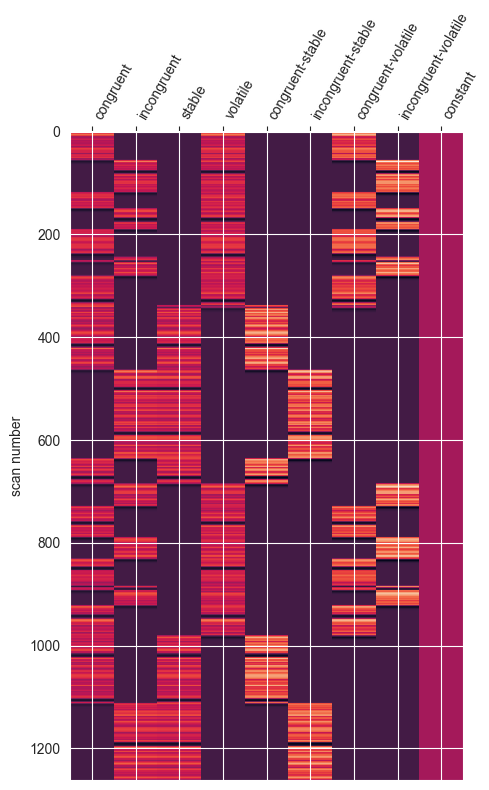

                      congruent  incongruent    stable  volatile  congruent-stable  incongruent-stable  congruent-volatile  incongruent-volatile  constant
congruent              1.000000    -0.781285  0.014022  0.238126          0.536019           -0.497855            0.650988             -0.461855  0.187075
incongruent           -0.781285     1.000000  0.220685 -0.027372         -0.421524            0.663599           -0.506142              0.561988 -0.271307
stable                 0.014022     0.220685  1.000000 -0.772655          0.576691            0.620898           -0.502659             -0.400568 -0.271136
volatile               0.238126    -0.027372 -0.772655  1.000000         -0.449749           -0.475742            0.674190              0.490551  0.194838
congruent-stable       0.536019    -0.421524  0.576691 -0.449749          1.000000           -0.282344           -0.291886             -0.233994  0.021057
incongruent-stable    -0.497855     0.663599  0.620898 -0.475742      

/Users/kenneth.van.der.zee/Documents/phd_1_analysis/venv/lib/python3.10/site-packages/nilearn/glm/_utils.py:180: UserWarning: Matrix is singular at working precision, regularizing...
  warn("Matrix is singular at working precision, regularizing...")


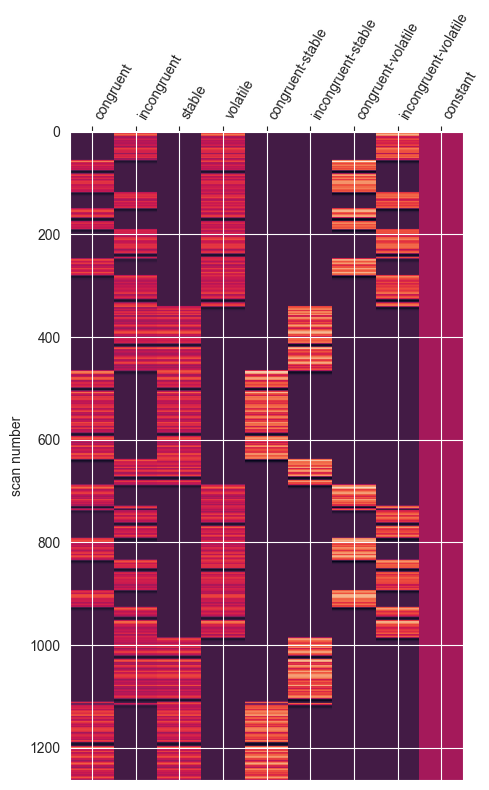

                      congruent  incongruent    stable  volatile  congruent-stable  incongruent-stable  congruent-volatile  incongruent-volatile  constant
congruent              1.000000    -0.780534  0.220817 -0.031734          0.663391           -0.417729            0.561777             -0.506085  0.410824
incongruent           -0.780534     1.000000  0.013604  0.242758         -0.496063            0.531149           -0.462517              0.651993 -0.666889
stable                 0.220817     0.013604  1.000000 -0.773308          0.619959            0.581158           -0.399419             -0.504739  0.125472
volatile              -0.031734     0.242758 -0.773308  1.000000         -0.475968           -0.452993            0.485126              0.679046 -0.407382
congruent-stable       0.663391    -0.496063  0.619959 -0.475968          1.000000           -0.278234           -0.246361             -0.310229  0.412390
incongruent-stable    -0.417729     0.531149  0.581158 -0.452993      

/Users/kenneth.van.der.zee/Documents/phd_1_analysis/venv/lib/python3.10/site-packages/nilearn/glm/_utils.py:180: UserWarning: Matrix is singular at working precision, regularizing...
  warn("Matrix is singular at working precision, regularizing...")


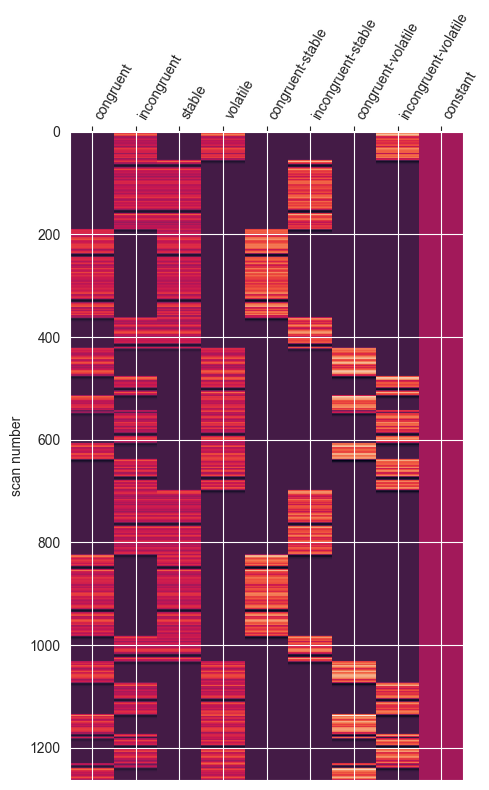

                      congruent  incongruent    stable  volatile  congruent-stable  incongruent-stable  congruent-volatile  incongruent-volatile  constant
congruent              1.000000    -0.780500  0.159836  0.055923          0.665507           -0.472297            0.565253             -0.445414 -0.620053
incongruent           -0.780500     1.000000  0.074599  0.155539         -0.513931            0.593428           -0.447255              0.582486  0.246359
stable                 0.159836     0.074599  1.000000 -0.773449          0.573731            0.588584           -0.426181             -0.506241 -0.013535
volatile               0.055923     0.155539 -0.773449  1.000000         -0.430509           -0.468311            0.548545              0.656750 -0.365189
congruent-stable       0.665507    -0.513931  0.573731 -0.430509          1.000000           -0.324456           -0.239532             -0.279690 -0.192725
incongruent-stable    -0.472297     0.593428  0.588584 -0.468311      

/Users/kenneth.van.der.zee/Documents/phd_1_analysis/venv/lib/python3.10/site-packages/nilearn/glm/_utils.py:180: UserWarning: Matrix is singular at working precision, regularizing...
  warn("Matrix is singular at working precision, regularizing...")


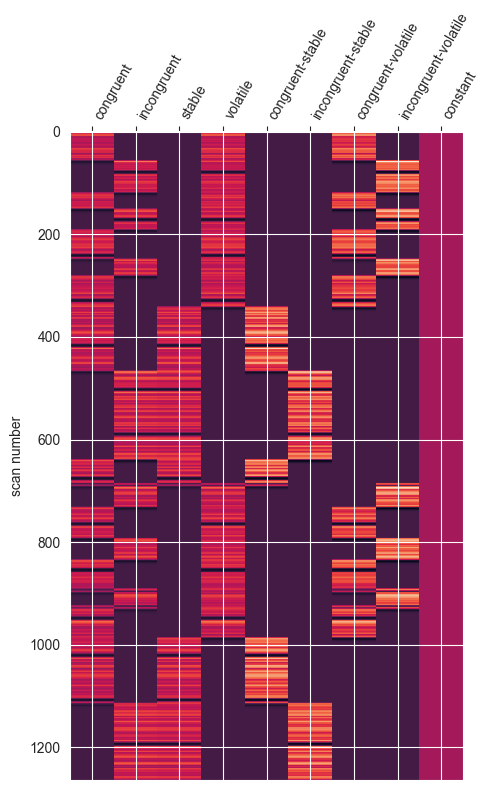

                      congruent  incongruent    stable  volatile  congruent-stable  incongruent-stable  congruent-volatile  incongruent-volatile  constant
congruent              1.000000    -0.779437  0.008548  0.240583          0.532424           -0.500626            0.648097             -0.455963  0.211225
incongruent           -0.779437     1.000000  0.225710 -0.028377         -0.417141            0.665535           -0.503216              0.559173 -0.549888
stable                 0.008548     0.225710  1.000000 -0.773657          0.577561            0.622016           -0.509985             -0.397855  0.232910
volatile               0.240583    -0.028377 -0.773657  1.000000         -0.452116           -0.476161            0.677922              0.492066 -0.568633
congruent-stable       0.532424    -0.417141  0.577561 -0.452116          1.000000           -0.279952           -0.299579             -0.230666  0.456780
incongruent-stable    -0.500626     0.665535  0.622016 -0.476161      

/Users/kenneth.van.der.zee/Documents/phd_1_analysis/venv/lib/python3.10/site-packages/nilearn/glm/_utils.py:180: UserWarning: Matrix is singular at working precision, regularizing...
  warn("Matrix is singular at working precision, regularizing...")


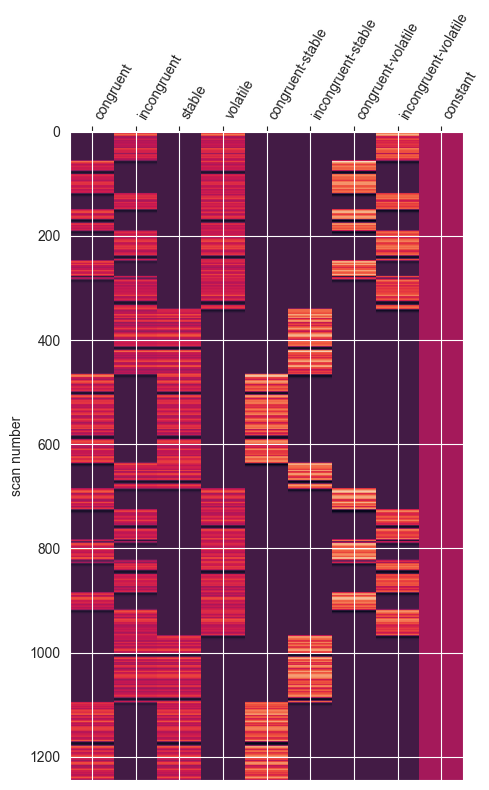

                      congruent  incongruent    stable  volatile  congruent-stable  incongruent-stable  congruent-volatile  incongruent-volatile  constant
congruent              1.000000    -0.787039  0.221456 -0.031409          0.668698           -0.423401            0.555835             -0.502895 -0.229764
incongruent           -0.787039     1.000000  0.006543  0.233347         -0.508409            0.535360           -0.457456              0.641338 -0.006870
stable                 0.221456     0.006543  1.000000 -0.782603          0.618231            0.579011           -0.402541             -0.518597 -0.489632
volatile              -0.031409     0.233347 -0.782603  1.000000         -0.478052           -0.459129            0.493536              0.680209  0.257817
congruent-stable       0.668698    -0.508409  0.618231 -0.478052          1.000000           -0.282876           -0.246409             -0.316348 -0.348052
incongruent-stable    -0.423401     0.535360  0.579011 -0.459129      

/Users/kenneth.van.der.zee/Documents/phd_1_analysis/venv/lib/python3.10/site-packages/nilearn/glm/_utils.py:180: UserWarning: Matrix is singular at working precision, regularizing...
  warn("Matrix is singular at working precision, regularizing...")


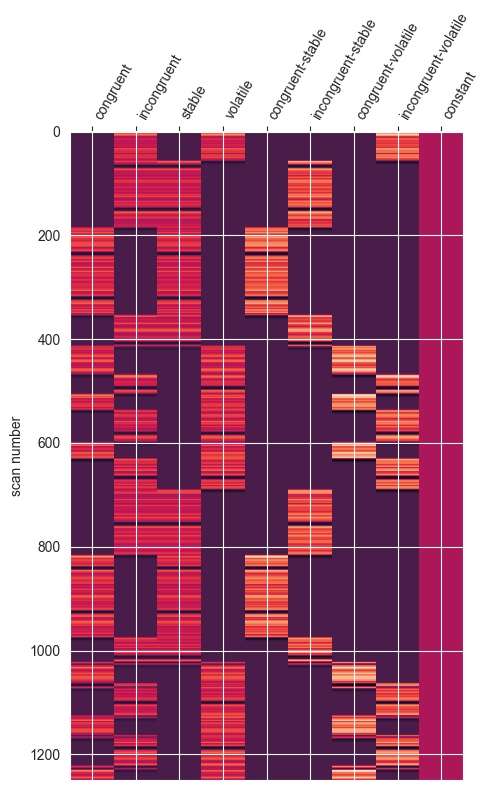

                      congruent  incongruent    stable  volatile  congruent-stable  incongruent-stable  congruent-volatile  incongruent-volatile  constant
congruent              1.000000    -0.776376  0.167923  0.050011          0.670534           -0.468892            0.559797             -0.442279 -0.423837
incongruent           -0.776376     1.000000  0.068816  0.165863         -0.518006            0.591762           -0.437495              0.581966 -0.037973
stable                 0.167923     0.068816  1.000000 -0.770881          0.574844            0.587671           -0.422295             -0.511718  0.044053
volatile               0.050011     0.165863 -0.770881  1.000000         -0.431373           -0.464657            0.547265              0.664294 -0.513014
congruent-stable       0.670534    -0.518006  0.574844 -0.431373          1.000000           -0.324236           -0.239380             -0.283607  0.005537
incongruent-stable    -0.468892     0.591762  0.587671 -0.464657      

/Users/kenneth.van.der.zee/Documents/phd_1_analysis/venv/lib/python3.10/site-packages/nilearn/glm/_utils.py:180: UserWarning: Matrix is singular at working precision, regularizing...
  warn("Matrix is singular at working precision, regularizing...")


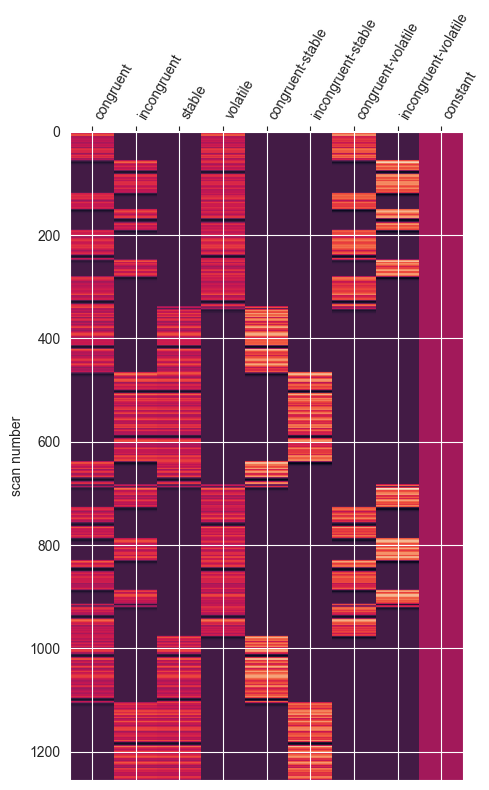

                      congruent  incongruent    stable  volatile  congruent-stable  incongruent-stable  congruent-volatile  incongruent-volatile  constant
congruent              1.000000    -0.779453  0.005631  0.245722          0.533169           -0.501469            0.651575             -0.456351  0.152519
incongruent           -0.779453     1.000000  0.232651 -0.035593         -0.416400            0.669227           -0.507137              0.556554 -0.349627
stable                 0.005631     0.232651  1.000000 -0.771598          0.573225            0.624764           -0.507628             -0.394980 -0.362456
volatile               0.245722    -0.035593 -0.771598  1.000000         -0.446940           -0.477645            0.678334              0.487610  0.172449
congruent-stable       0.533169    -0.416400  0.573225 -0.446940          1.000000           -0.281666           -0.294369             -0.228395  0.011683
incongruent-stable    -0.501469     0.669227  0.624764 -0.477645      

/Users/kenneth.van.der.zee/Documents/phd_1_analysis/venv/lib/python3.10/site-packages/nilearn/glm/_utils.py:180: UserWarning: Matrix is singular at working precision, regularizing...
  warn("Matrix is singular at working precision, regularizing...")


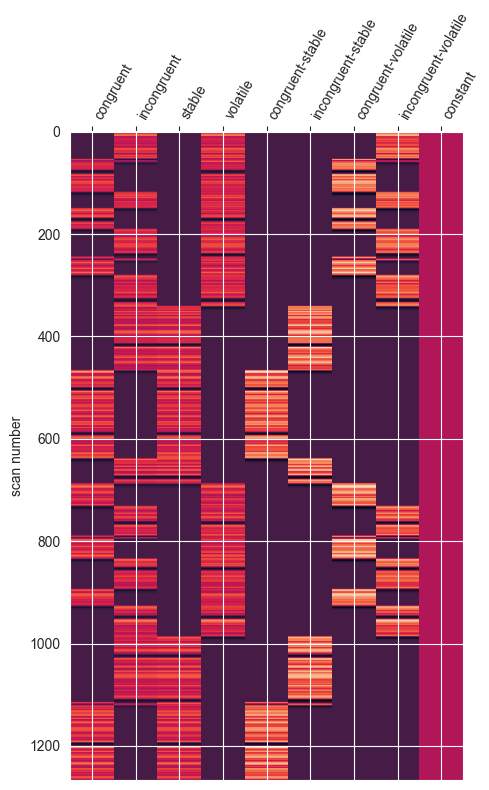

                      congruent  incongruent    stable  volatile  congruent-stable  incongruent-stable  congruent-volatile  incongruent-volatile  constant
congruent              1.000000    -0.779721  0.220472 -0.032500          0.667315           -0.421582            0.556153             -0.500083 -0.695529
incongruent           -0.779721     1.000000  0.014064  0.243195         -0.498365            0.533248           -0.458143              0.648054  0.244271
stable                 0.220472     0.014064  1.000000 -0.774318          0.618631            0.581453           -0.403529             -0.507601 -0.412356
volatile              -0.032500     0.243195 -0.774318  1.000000         -0.474492           -0.454915            0.487199              0.683902 -0.024398
congruent-stable       0.667315    -0.498365  0.618631 -0.474492          1.000000           -0.279510           -0.247839             -0.310581 -0.405467
incongruent-stable    -0.421582     0.533248  0.581453 -0.454915      

/Users/kenneth.van.der.zee/Documents/phd_1_analysis/venv/lib/python3.10/site-packages/nilearn/glm/_utils.py:180: UserWarning: Matrix is singular at working precision, regularizing...
  warn("Matrix is singular at working precision, regularizing...")


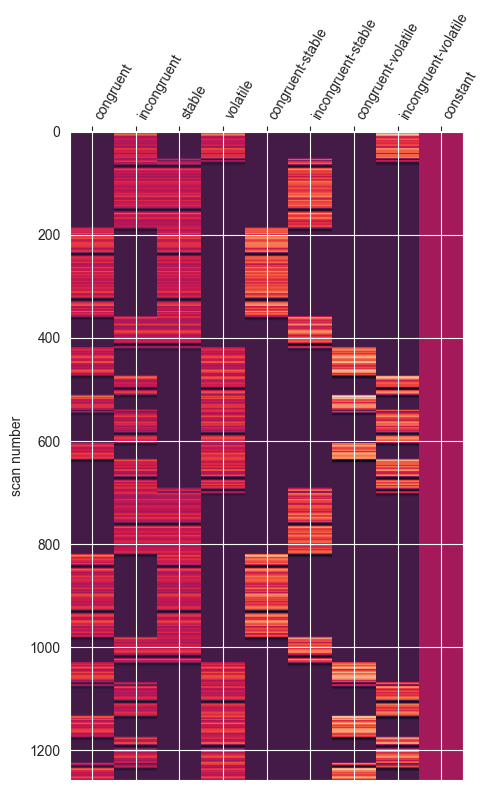

                      congruent  incongruent    stable  volatile  congruent-stable  incongruent-stable  congruent-volatile  incongruent-volatile  constant
congruent              1.000000    -0.778665  0.164527  0.053471          0.666055           -0.477537            0.561790             -0.446390  0.052103
incongruent           -0.778665     1.000000  0.066228  0.167409         -0.513964            0.592881           -0.442627              0.593655 -0.339701
stable                 0.164527     0.066228  1.000000 -0.769562          0.581846            0.577414           -0.431355             -0.498450 -0.263409
volatile               0.053471     0.167409 -0.769562  1.000000         -0.434305           -0.457870            0.551226              0.656112 -0.031090
congruent-stable       0.666055    -0.513964  0.581846 -0.434305          1.000000           -0.328054           -0.242887             -0.281799 -0.067599
incongruent-stable    -0.477537     0.592881  0.577414 -0.457870      

/Users/kenneth.van.der.zee/Documents/phd_1_analysis/venv/lib/python3.10/site-packages/nilearn/glm/_utils.py:180: UserWarning: Matrix is singular at working precision, regularizing...
  warn("Matrix is singular at working precision, regularizing...")


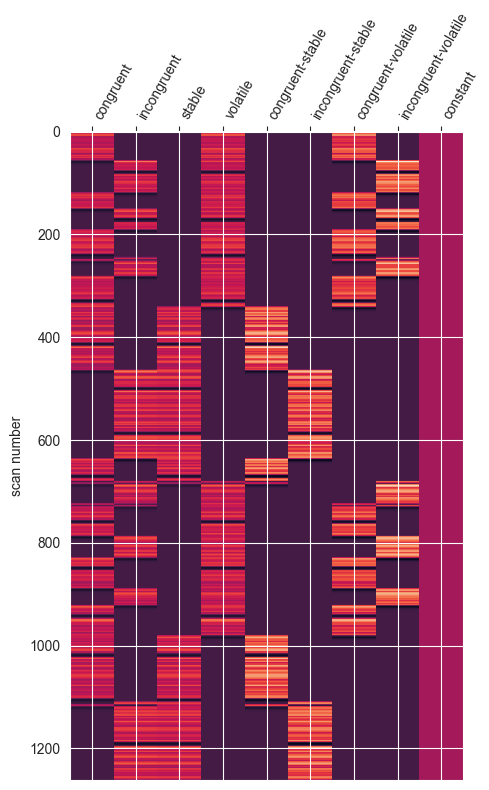

                      congruent  incongruent    stable  volatile  congruent-stable  incongruent-stable  congruent-volatile  incongruent-volatile  constant
congruent              1.000000    -0.779841  0.004708  0.248574          0.528654           -0.498850            0.653518             -0.457858 -0.642747
incongruent           -0.779841     1.000000  0.229342 -0.036188         -0.418013            0.667727           -0.504515              0.555798  0.112353
stable                 0.004708     0.229342  1.000000 -0.773148          0.574384            0.624550           -0.506885             -0.398984 -0.366575
volatile               0.248574    -0.036188 -0.773148  1.000000         -0.450660           -0.476595            0.681481              0.485141 -0.182920
congruent-stable       0.528654    -0.418013  0.574384 -0.450660          1.000000           -0.280571           -0.297010             -0.230709 -0.424188
incongruent-stable    -0.498850     0.667727  0.624550 -0.476595      

In [66]:
for subject_id in unique_subject_ids:
    for session in unique_sessions:
        print(f'Creating event file for subject {subject_id} and session {session}')
        dataframe = combined_dataframe[combined_dataframe['subject_id'] == f'sub-{subject_id:03}']
        dataframe = dataframe[dataframe['session'] == f'session-{session:02}']

        # Note down when each trial and each response starts
        dataframe['emotional_cue_time'] = dataframe['trial_duration'].shift(fill_value=0).cumsum()
        dataframe['response_time'] = dataframe['emotional_cue_time'] + dataframe['RT_s']

        # Combine variables
        dataframe['congruency-volatility'] = dataframe['congruency'] + '-' + dataframe['volatility']
        dataframe['onset'] = dataframe['emotional_cue_time']
        # Create a boxcar of 1.8s
        dataframe['duration'] = 1.8
        print(dataframe[['valence','congruency','volatility','congruency-volatility','duration']])

        # Restructure into a time-series
        restructured_rows = []
        for _, row in dataframe.iterrows():
            restructured_rows.append({'trial_type': row['congruency'], 'onset': row['onset'], 'duration': row['duration']})
            restructured_rows.append({'trial_type': row['volatility'], 'onset': row['onset'], 'duration': row['duration']})
            restructured_rows.append({'trial_type': row['congruency-volatility'], 'onset': row['onset'], 'duration': row['duration']})

        # Convert to dataframe
        data_design_matrix = pd.DataFrame(restructured_rows)
        print(data_design_matrix)

        # Now create the design matrix and save it
        events = pd.DataFrame(
            {"trial_type": data_design_matrix['trial_type'], "onset": data_design_matrix['onset'], "duration": data_design_matrix['duration']}
        )
        print(events)
        events.to_csv(os.path.join(f'/Volumes/project/3025011.02/bids/sub-{subject_id:03}/ses-mri{session:02}/func/sub-{subject_id:03}_ses-mri{session:02}_task-AARL_events.tsv'), sep='\t')

        # Scanner info
        # Repetition time
        tr = 1.5

        # Define scan volumes
        time_length = math.ceil(max(data_design_matrix['onset']))
        n_volumes = np.arange(0, time_length, tr)
        total_volumes = len(n_volumes)
        print(n_volumes)

        # fit the hemodynamic response function to the event file
        design_matrix = make_first_level_design_matrix(
            n_volumes,
            data_design_matrix,
            drift_model = None
        )
        design_matrix = design_matrix[['congruent','incongruent','stable','volatile','congruent-stable','incongruent-stable','congruent-volatile','incongruent-volatile','constant']]

        # Plot said matrix and save it
        fig, ax = plt.subplots(figsize=(5, 8), nrows=1, ncols=1)
        plot_design_matrix(design_matrix, ax=ax)
        plt.savefig(os.path.join(output_dir, f'design_matrix_sub-{subject_id:03}_ses-mri{session:02}.pdf'))
        plt.show()

        # Now also plot the correlation matrix and save it
        pd.set_option('display.width', 200)
        correlation_matrix = design_matrix.corr()
        correlation_matrix.round(3).to_csv(os.path.join(output_dir, f'regression_correlation_matrix_sub-{subject_id:03}_ses-mri{session:02}.csv'), sep=';')
        print(correlation_matrix)

In [35]:
dataframe['emotional_cue_time'] = dataframe['trial_duration'].shift(fill_value=0).cumsum()
dataframe['response_time'] = dataframe['emotional_cue_time'] + dataframe['RT_s']

print(dataframe)

     trial  emotional_cue_time response objectively_correct  subjectively_correct  response_time   RT_s  feedback_time  stimuli_type  trial_duration  ...  stay_shift  volatility  \
0        8            0.000000       up                True                 False       0.573000  0.573   1.748355e+09             2        3.083958  ...           0    volatile   
0        9            3.083958     down                True                  True       4.017958  0.934   1.748355e+09             1        3.353823  ...           0    volatile   
1       10            6.437781     down               False                  True       6.975781  0.538   1.748355e+09             2        4.676162  ...           0    volatile   
1       11           11.113943       up               False                  True      11.763943  0.650   1.748355e+09             1        4.448276  ...           0    volatile   
2       12           15.562219       up               False                 False      16.22521

# Quickly recode into something the design matrix can use

In [36]:
print(dataframe['congruency'])

0      incongruent
0      incongruent
1      incongruent
1      incongruent
2      incongruent
          ...     
217      congruent
218      congruent
219      congruent
218      congruent
220    incongruent
Name: congruency, Length: 440, dtype: object


In [37]:
dataframe['congruency-volatility'] = dataframe['congruency'] + '-' + dataframe['volatility']

dataframe['onset'] = dataframe['emotional_cue_time']
dataframe['duration'] = 1.8
print(dataframe[['valence','congruency','volatility','congruency-volatility','duration']])

    valence   congruency volatility congruency-volatility  duration
0     happy  incongruent   volatile  incongruent-volatile       1.8
0     angry  incongruent   volatile  incongruent-volatile       1.8
1     happy  incongruent   volatile  incongruent-volatile       1.8
1     angry  incongruent   volatile  incongruent-volatile       1.8
2     angry  incongruent   volatile  incongruent-volatile       1.8
..      ...          ...        ...                   ...       ...
217   happy    congruent     stable      congruent-stable       1.8
218   angry    congruent     stable      congruent-stable       1.8
219   angry    congruent     stable      congruent-stable       1.8
218   happy    congruent     stable      congruent-stable       1.8
220   angry  incongruent     stable    incongruent-stable       1.8

[440 rows x 5 columns]


# Restructure the data into a timeseries

In [38]:
# Create the new dataframe by transforming the data
restructured_rows = []
for _, row in dataframe.iterrows():
    restructured_rows.append({'trial_type': row['congruency'], 'onset': row['onset'], 'duration': row['duration']})
    restructured_rows.append({'trial_type': row['volatility'], 'onset': row['onset'], 'duration': row['duration']})
    restructured_rows.append({'trial_type': row['congruency-volatility'], 'onset': row['onset'], 'duration': row['duration']})

# Convert to dataframe
data_design_matrix = pd.DataFrame(restructured_rows)

print(data_design_matrix)

                trial_type        onset  duration
0              incongruent     0.000000       1.8
1                 volatile     0.000000       1.8
2     incongruent-volatile     0.000000       1.8
3              incongruent     3.083958       1.8
4                 volatile     3.083958       1.8
...                    ...          ...       ...
1315                stable  1895.520240       1.8
1316      congruent-stable  1895.520240       1.8
1317           incongruent  1898.601199       1.8
1318                stable  1898.601199       1.8
1319    incongruent-stable  1898.601199       1.8

[1320 rows x 3 columns]


# Scanner info

In [39]:
# Repetition time
tr = 1.5

# Define scan volumes
time_length = math.ceil(max(data_design_matrix['onset']))
n_volumes = np.arange(0, time_length, tr)
total_volumes = len(n_volumes)
print(n_volumes)

[0.0000e+00 1.5000e+00 3.0000e+00 ... 1.8945e+03 1.8960e+03 1.8975e+03]


# Design matrix

In [40]:
events = pd.DataFrame(
    {"trial_type": data_design_matrix['trial_type'], "onset": data_design_matrix['onset'], "duration": data_design_matrix['duration']}
)
print(events)

                trial_type        onset  duration
0              incongruent     0.000000       1.8
1                 volatile     0.000000       1.8
2     incongruent-volatile     0.000000       1.8
3              incongruent     3.083958       1.8
4                 volatile     3.083958       1.8
...                    ...          ...       ...
1315                stable  1895.520240       1.8
1316      congruent-stable  1895.520240       1.8
1317           incongruent  1898.601199       1.8
1318                stable  1898.601199       1.8
1319    incongruent-stable  1898.601199       1.8

[1320 rows x 3 columns]


In [41]:
design_matrix = make_first_level_design_matrix(
    n_volumes,
    data_design_matrix,
    drift_model = None
)
design_matrix = design_matrix[['congruent','incongruent','stable','volatile','congruent-stable','incongruent-stable','congruent-volatile','incongruent-volatile','constant']]
print(design_matrix)

           congruent   incongruent        stable      volatile  congruent-stable  incongruent-stable  congruent-volatile  incongruent-volatile  constant
0.0    -1.039887e-14  6.877288e-16 -1.728428e-15 -1.126467e-14      1.018885e-14       -2.253613e-16        2.065424e-14          8.669693e-15       1.0
1.5    -1.756340e-14  4.070965e-03 -9.296427e-15  4.070965e-03      2.143085e-14        4.278854e-15        1.109163e-14          4.070965e-03       1.0
3.0    -5.023859e-16  1.060220e-01 -9.216761e-16  1.060220e-01     -9.370459e-16       -2.728961e-16       -3.687431e-16          1.060220e-01       1.0
4.5    -1.129098e-14  3.634838e-01  1.817916e-14  3.634838e-01     -4.251890e-15        1.552515e-14        2.118322e-16          3.634838e-01       1.0
6.0     1.025706e-14  5.802575e-01 -2.524213e-14  5.802575e-01      8.834607e-15        2.505864e-14       -9.304207e-15          5.802575e-01       1.0
...              ...           ...           ...           ...               ...  

/Users/kenneth.van.der.zee/Documents/phd_1_analysis/venv/lib/python3.10/site-packages/nilearn/glm/_utils.py:180: UserWarning: Matrix is singular at working precision, regularizing...
  warn("Matrix is singular at working precision, regularizing...")


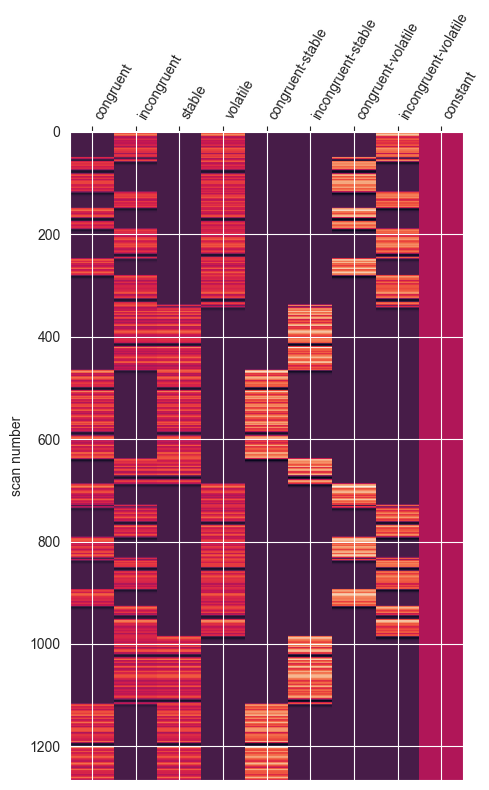

In [46]:
fig, ax = plt.subplots(figsize=(5, 8), nrows=1, ncols=1)
plot_design_matrix(design_matrix, ax=ax)
plt.savefig(os.path.join(output_dir, f'design_matrix_sub-{unique_subject_ids[0]:03}.pdf'))
plt.show()

## Correlation matrix of the regressors

In [47]:
pd.set_option('display.width', 200)
correlation_matrix = design_matrix.corr()
correlation_matrix.round(3).to_csv(os.path.join(output_dir, f'regression_correlation_matrix_sub-{unique_subject_ids[0]:03}.csv'), sep=';')
print(correlation_matrix)

                      congruent  incongruent    stable  volatile  congruent-stable  incongruent-stable  congruent-volatile  incongruent-volatile  constant
congruent              1.000000    -0.778969  0.221960 -0.029968          0.668221           -0.423073            0.555647             -0.499817 -0.305586
incongruent           -0.778969     1.000000  0.014603  0.240794         -0.499327            0.536928           -0.456520              0.647233  0.200533
stable                 0.221960     0.014603  1.000000 -0.773000          0.620158            0.578783           -0.403974             -0.506445 -0.495551
volatile              -0.029968     0.240794 -0.773000  1.000000         -0.474709           -0.452257            0.491482              0.681328  0.402401
congruent-stable       0.668221    -0.499327  0.620158 -0.474709          1.000000           -0.280790           -0.247249             -0.311717 -0.449152
incongruent-stable    -0.423073     0.536928  0.578783 -0.452257      